# Исследование стартапов и инвестиционной активности



## Введение

**Цель проекта:**

Проанализировать рынок финансирования стартапов для выявления наиболее перспективных рыночных сегментов и типов финансирования с целью формирования инвестиционной стратегии на 2015 год.

**Задачи проекта**

1. Провести загрузку и предобработку данных:
- Оценить объём, полноту и качество данных.
- Привести названия столбцов к единому стилю.
- Обработать пропущенные и аномальные значения, в частности в ключевых столбцах funding_total_usd и mid_funding_at.
- Обработать типы данных. 
- Удалить неинформативные записи и полные дубликаты.
2. Провести инжиниринг признаков:
- Классифицировать компании по длительности цикла финансирования (единичное, до года, более года).
- Сегментировать рынок на массовые, средние и нишевые категории на основе частоты встречаемости и объединить не-массовые сегменты.
3. Выполнить анализ данных и выбросов:
- Выявить и исключить компании с аномальным объёмом финансирования с помощью метода IQR в разрезе сегментов.
- Определить временные границы данных (годы с 50+ раундами финансирования).
- Проанализировать типы финансирования по объёму привлечённых средств и популярности.
4. Исследовать динамику ключевых показателей:
- Проанализировать динамику типичного размера раунда и общей активности на рынке инвестиций по годам.
- Выявить массовые рыночные сегменты, показавшие рост в 2014 году, и проанализировать их динамику.
- Рассчитать и визуализировать годовую динамику доли возвращённых средств.
5. Сформулировать итоговые выводы и рекомендации.




### Содержание проекта


1. Загрузка данных и знакомство с ними

 1.1 Предобработка данных
 
 
2. Инжиниринг признаков

  2.1. Группы по срокам финансирования
  
  2.2 Выделение средних и нишевых сегментов рынка
  
  
3. Работа с выбросами и анализ

 3.1. Анализируем и помечаем выбросы в каждом из сегментов
 
 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии
 
 3.3. Анализ типов финансирования по объёму и популярности
 
 
4. Анализ динамики

 4.1 Динамика предоставления финансирования по годам
 
 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов
 
 4.3 Годовая динамика доли возвращённых средств по типам финансировани
 
 
5. Итоговый вывод и рекомендации


## Знакомство с данными: загрузка и предобработка

Данные представлены основным и вспомогательным датасетами : датасет - `cb_investments`содержит основную информацию, дополнительного датасета — `cb_returns`, содержит суммы возвратов по типам финансирования в миллионах долларов по годам.


### 1.1. Вывод общей информации

Загружаем необходимые для работы библиотеки.



In [1]:
!pip install phik -q 
!pip install missingno

In [2]:
# Импортируем библиотеки
import pandas as pd

import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
from matplotlib import cm

import seaborn as sns

import missingno as msno



Загружаем данные по проекту.

In [3]:
# Загружаем файл cb_investments.csv. и создаем копию
df_invest = pd.read_csv("/datasets/cb_investments.zip", sep=';',
                        compression = 'zip',
                        low_memory=False)
df_invest_orig = df_invest.copy()

In [4]:
# Загружаем файл cb_returns.csv.
df_returns = pd.read_csv('/datasets/cb_returns.csv', index_col=0)

Выводим информацию, которая необходима для принятия решений о предобработке.

In [5]:
# Выводим информацию о датафрейме 
print('Информация о файле с инвестициями', '\n')
print(df_invest.info())

Информация о файле с инвестициями 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-nu

In [6]:
# Подсчитаем количество строк с пропусками
missing_raw = df_invest.isna().sum()

# Подсчитываем долю строк с пропусками
missing_percent = round((df_invest.isna().sum() / df_invest.shape[0]),2)*100

missing_data = pd.DataFrame ({
    'Абсолютное значение': missing_raw,
    'Относительное значение': missing_percent
})

print('Пропущенные значения')
display(missing_data)

Пропущенные значения


,Абсолютное значение,Относительное значение
name,4857,9.0
homepage_url,8305,15.0
category_list,8817,16.0
market,8817,16.0
funding_total_usd,4856,9.0
status,6170,11.0
country_code,10129,19.0
state_code,24133,44.0
region,10129,19.0
city,10972,20.0


<Figure size 720x432 with 0 Axes>

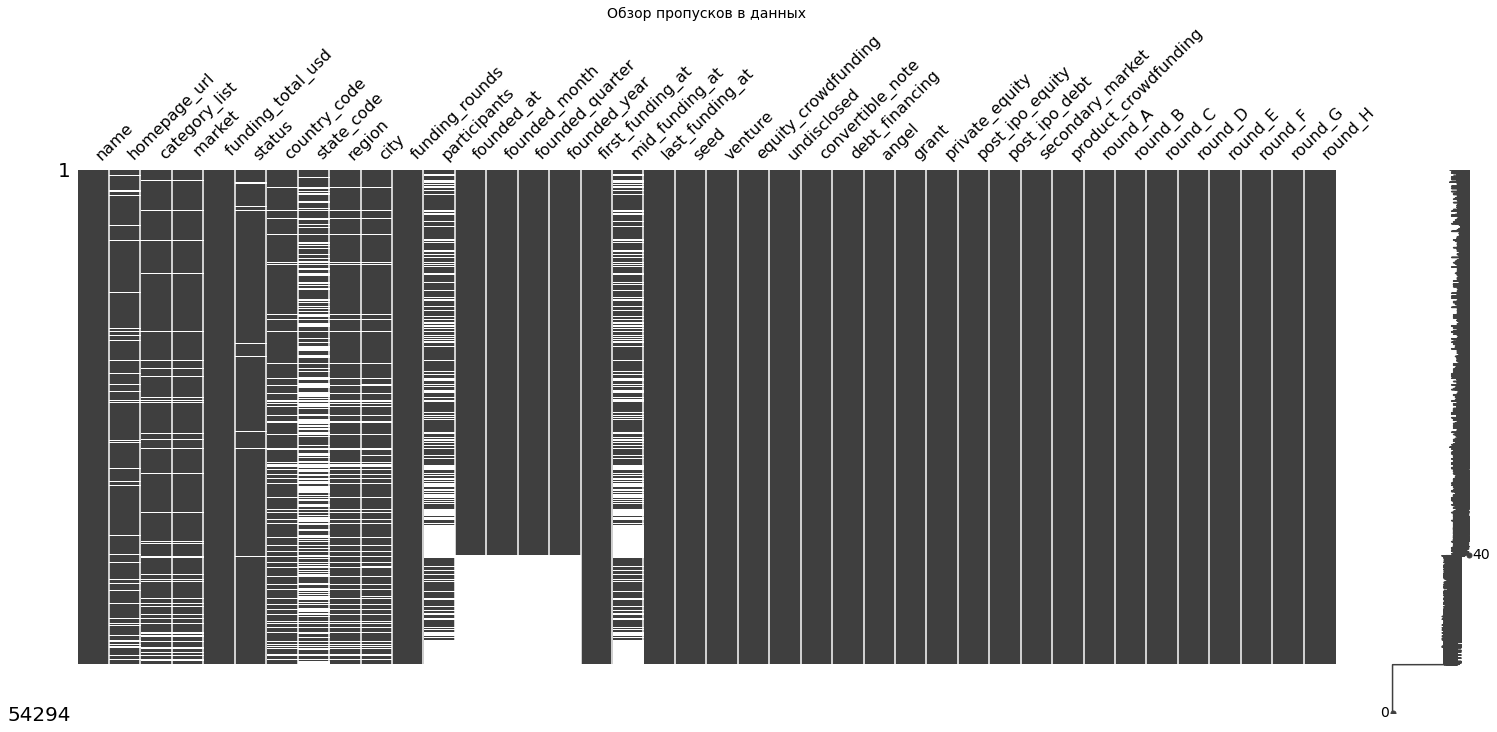

In [7]:
# Визуализация пропусков
plt.figure(figsize = (10,6))
msno.matrix(df_invest)

plt.title('Обзор пропусков в данных', fontsize = 14)

plt.show()

In [8]:
# Выводим несколько строк датафрейма 
display(df_invest.head(10))


,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Xavier University,http://www.xavier.edu/,NaN,NaN,"1,90,00,000",operating,USA,OH,Cincinnati,Cincinnati,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Tulane University,http://tulane.edu/,|Education|,Education,"1,20,00,000",operating,USA,LA,New Orleans,New Orleans,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,Duke University,http://www.duke.edu,|Education|,Education,"87,00,000",operating,USA,NC,Raleigh,Durham,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,"Virginia Commonwealth University, Richmond",http://www.vcu.edu/,NaN,NaN,"60,00,000",operating,USA,VA,Richmond,Richmond,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,WeGame,http://www.WeGame.com,|Social Media|,Social Media,"35,00,000",acquired,USA,CA,SF Bay Area,San Francisco,...,0.0,0.0,3000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Датасет 'cb_investments'** содержит 40 столбцов и 54293 строк, 
в которых представлена детальная информация о компаниях, их финансировании и деятельности.

После первичного анализа данных можно сделать следующие выводы:
- Необходимо превести названия столбцов к единому стилю
- Наблюдаются массовые пропуски в ключевых полях.
- Большинство числовых столбцов (funding_total_usd, seed, venture, и т.д.) имеют тип данных object, потому что в данных встречаются: запятые как разделители, строки - или n/a вместо чисел. Эти поля нужно очистить и привести к числовому типу (float).
- Даты (founded_at, first_funding_at, last_funding_at) — строки, нужно преобразовать в формат datetime.


In [9]:
# Выводим информацию о датафрейме
print('Информация о доп. файле с суммами возвратов', '\n')
print(df_returns.info())

Информация о доп. файле с суммами возвратов 

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15 entries, 2000 to 2014
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   seed                  15 non-null     float64
 1   venture               15 non-null     float64
 2   equity_crowdfunding   15 non-null     float64
 3   undisclosed           15 non-null     float64
 4   convertible_note      15 non-null     float64
 5   debt_financing        15 non-null     float64
 6   angel                 15 non-null     float64
 7   grant                 15 non-null     float64
 8   private_equity        15 non-null     float64
 9   post_ipo_equity       15 non-null     float64
 10  post_ipo_debt         15 non-null     float64
 11  secondary_market      15 non-null     float64
 12  product_crowdfunding  15 non-null     float64
dtypes: float64(13)
memory usage: 1.6 KB
None


<Figure size 720x432 with 0 Axes>

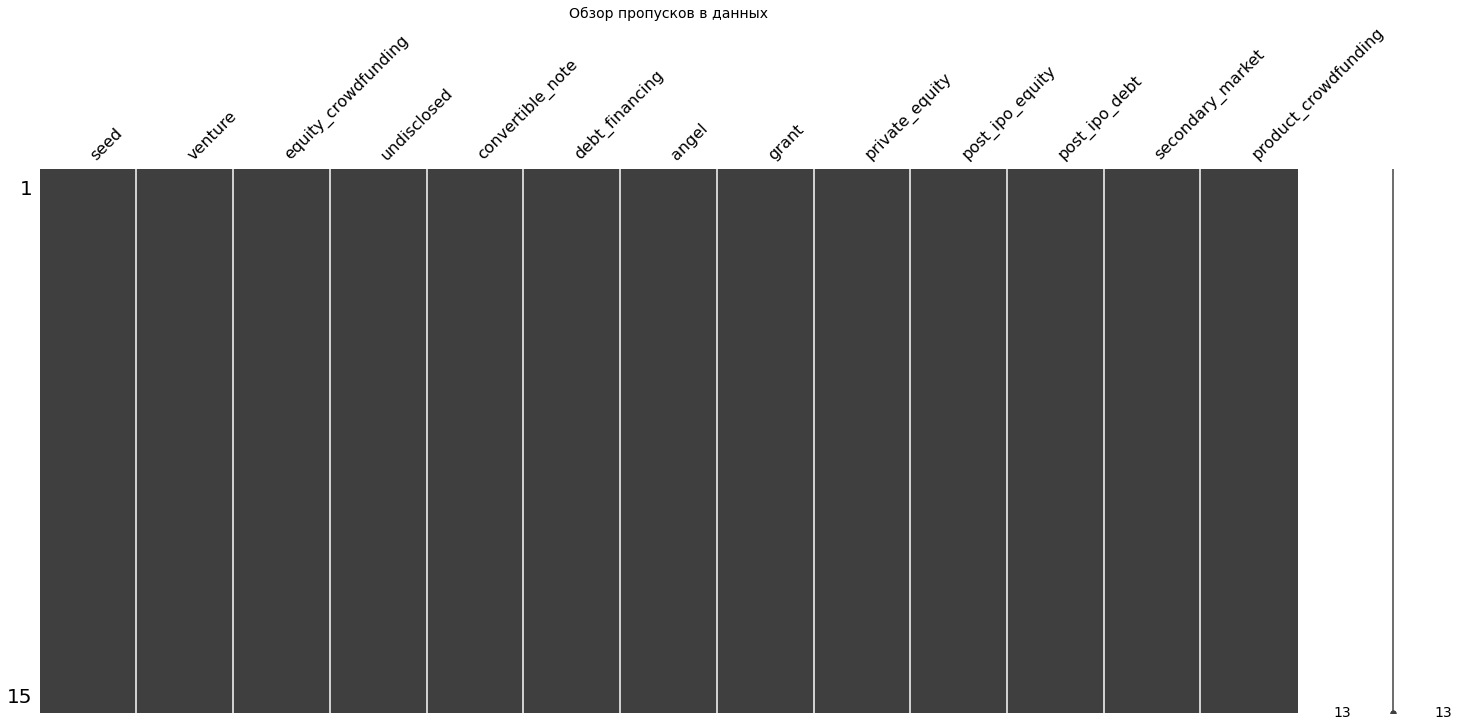

In [10]:
# Визуализация пропусков
plt.figure(figsize = (10,6))
msno.matrix(df_returns)

plt.title('Обзор пропусков в данных', fontsize = 14)

plt.show()

In [11]:
# Выводим несколько строк датафрейма
display(df_returns.head(15))

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00


**Датасет 'cb_returns'** содержит 14 столбцов и 15 строк, 
в которых представлены агрегированные показатели доходности. Датасет является дополнительным

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов в едином стиле
- Пропуски отсутствуют
- Дубликатов нет 

**Общий вывод:**

Данные тебуют тщательной подготовки. Особое внимание следует уделить финансовым показателям, так как они являются основой для последующего анализа.

Сделайте вывод о полученных данных: каков их объём, соответствуют ли данные описанию, есть ли пропущенные значения, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

### 1.2. Предобработка данных

Проверяем названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. 

In [12]:
print("\nСтолбцы датафрейма инвестиций",df_invest.columns.tolist())
print("\nСтолбцы датафрейма возвратов сумм",df_returns.columns.tolist())


Столбцы датафрейма инвестиций ['name', 'homepage_url', 'category_list', ' market ', ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']

Столбцы датафрейма возвратов сумм ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']


Названия столбцов в returns соответствует стандарту. 

Названия столбцов в investments необходимо привести стандарту, есть заглавные буквы и лишние пробелы в названиях столбцов

In [13]:
# Удаляем пробелы в начале и конце, приводим к нижнему регистру и заменяем пробелы на подчеркивания 
df_invest.columns = [col.strip().lower().replace(' ', '_') for col in df_invest.columns] 

# Выводим столбцы
print("\nОбработанные названия столбцов датафрейма инвестиций:")
print(df_invest.columns.tolist())



Обработанные названия столбцов датафрейма инвестиций:
['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_a', 'round_b', 'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h']


Уберите в столбце `funding_total_usd` выделение разрядов и приведите его к числовому типу.

In [14]:
# Убираем разделители, приводим к числовому формату
df_invest['funding_total_usd']= pd.to_numeric(df_invest['funding_total_usd'].str.replace(',',''),errors='coerce')
display(df_invest['funding_total_usd'].head(10))

print(df_invest['funding_total_usd'].dtype)

0    90000000.0
1     2000000.0
2     9000000.0
3     7700000.0
4      540000.0
5    19000000.0
6    12000000.0
7     8700000.0
8     6000000.0
9     3500000.0
Name: funding_total_usd, dtype: float64

float64


Обрабатываем типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.

In [15]:
# Преобразование столбцов с датами к типу datetime 

date_cols = ['founded_at','founded_month', 'first_funding_at', 'mid_funding_at', 'last_funding_at'] 

for col in date_cols:
    if col in df_invest.columns:
        df_invest[col] = pd.to_datetime(df_invest[col], errors='coerce')

# Проверка результата
print(df_invest.shape)
print(df_invest.info())

# Выводим строки столбцов с датами 
display(df_invest[date_cols].head(20))

(54294, 40)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  49437 non-null  object        
 1   homepage_url          45989 non-null  object        
 2   category_list         45477 non-null  object        
 3   market                45477 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                48124 non-null  object        
 6   country_code          44165 non-null  object        
 7   state_code            30161 non-null  object        
 8   region                44165 non-null  object        
 9   city                  43322 non-null  object        
 10  funding_rounds        49438 non-null  float64       
 11  participants          30473 non-null  float64       
 12  founded_at            38553 non-null  datetime64[ns]
 13  foun

,founded_at,founded_month,first_funding_at,mid_funding_at,last_funding_at
0,NaT,NaT,2014-01-06,NaT,2014-01-06
1,1785-01-01,NaT,2014-05-15,NaT,2014-05-15
2,1802-07-19,NaT,2009-07-02,2009-07-02,2009-07-02
3,1817-01-01,NaT,2013-11-21,2013-11-21,2014-11-03
4,1826-01-01,NaT,2014-01-14,NaT,2014-01-14
5,1831-01-01,NaT,2014-10-23,NaT,2014-10-23
6,1834-01-01,NaT,2013-09-05,2013-09-05,2013-12-22
7,1838-01-01,NaT,2014-01-12,NaT,2014-01-12
8,1838-01-01,NaT,2014-09-30,NaT,2014-09-30
9,1840-01-01,NaT,2007-10-01,2007-10-01,2008-03-01


Тип данных изменен в столбцах founded_at founded_month first_funding_at	mid_funding_at	last_funding_at на datetime. 
Столбец founded_year содержит только год и числовой формат подходит для хранения такого типа данных 
Столбец founded_quarter содержит буквенное обозначения квартала, для сохранения формата записи, оставим тип данных object

В датасете `cb_returns` сделайте столбец `year` индексом всего датасета, если не делали это при загрузке.

In [16]:
print(df_returns.columns)
display(df_returns.head())

Index(['seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')


,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


Столбец year сделан индексам при загрузке

Обрабатываем текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполним заглушками там, где это понадобится.

In [17]:
# Выводим столбцы с типом данных object 
text_cols = df_invest.select_dtypes(include='object').columns.tolist()
print(text_cols)

['name', 'homepage_url', 'category_list', 'market', 'status', 'country_code', 'state_code', 'region', 'city', 'founded_quarter']


In [18]:
# Перечислим столбцы в которых будут заглушки
placeholder_dict = {'name': 'unknown', 
                    'homepage_url': 'unknown', 
                    'category_list': 'unknown', 
                    'market': 'unknown', 
                    'status': 'unknown', 
                    'country_code': 'unknown', 
                    'state_code': 'unknown', 
                    'region': 'unknown', 
                    'city': 'unknown', 

}

# Форматируем все строки 'nan' и пустые строки для дальнейшей обработки
for col in text_cols:
    if col in df_invest.columns:
        df_invest[col] = df_invest[col].replace('nan', np.nan)  # строка nan
        df_invest[col] = df_invest[col].replace('', np.nan)     # пустая строка

# Заменяем пропуски заглушками
for col, placeholder in placeholder_dict.items():
    if col in df_invest.columns:
        df_invest[col] = df_invest[col].fillna(placeholder)


In [19]:
# Проверка результатов
display(df_invest.head(15))
print("\nИнформация о пропусках:")
print(df_invest.isnull().sum())

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,Harvard University,http://harvard.edu,|Education|,Education,90000000.0,operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,unknown,unknown,2000000.0,operating,unknown,unknown,unknown,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,540000.0,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Xavier University,http://www.xavier.edu/,unknown,unknown,19000000.0,operating,USA,OH,Cincinnati,Cincinnati,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Tulane University,http://tulane.edu/,|Education|,Education,12000000.0,operating,USA,LA,New Orleans,New Orleans,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,Duke University,http://www.duke.edu,|Education|,Education,8700000.0,operating,USA,NC,Raleigh,Durham,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,"Virginia Commonwealth University, Richmond",http://www.vcu.edu/,unknown,unknown,6000000.0,operating,USA,VA,Richmond,Richmond,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,WeGame,http://www.WeGame.com,|Social Media|,Social Media,3500000.0,acquired,USA,CA,SF Bay Area,San Francisco,...,0.0,0.0,3000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Информация о пропусках:
name                        0
homepage_url                0
category_list               0
market                      0
funding_total_usd       13387
status                      0
country_code                0
state_code                  0
region                      0
city                        0
funding_rounds           4856
participants            23821
founded_at              15741
founded_month           15812
founded_quarter         15812
founded_year            15740
first_funding_at         4866
mid_funding_at          24006
last_funding_at          4862
seed                     4856
venture                  4856
equity_crowdfunding      4856
undisclosed              4856
convertible_note         4856
debt_financing           4856
angel                    4856
grant                    4856
private_equity           4856
post_ipo_equity          4856
post_ipo_debt            4856
secondary_market         4856
product_crowdfunding     4856
round_a        

В текстовых столбцах к пропускам применена заглушка unknown. Столбец founded_quarter оставлен без изменений

In [20]:
# Нормализация текстовых столбцов
text_cols = df_invest.select_dtypes(include='object').columns
for col in text_cols:
    df_invest[col] = df_invest[col].astype(str)  # привести к строке
    df_invest[col] = df_invest[col].str.strip()    # обрезать пробелы по краям
    df_invest[col] = df_invest[col].str.lower()    # привести к нижнему регистру
    df_invest[col] = df_invest[col].str.replace(r'\s+', ' ', regex=True)  # нормализация пробелов

# Нормализации для category_list 
if 'category_list' in df_invest.columns:
    df_invest['category_list'] = df_invest['category_list'].str.replace(r'\s*\|\s*', '|', regex=True)
    df_invest['category_list'] = df_invest['category_list'].str.strip()
    
# Форматируем все строки nan и пустые строки после нормализации
for col in text_cols:
    if col in df_invest.columns:
        df_invest[col] = df_invest[col].replace('nan', np.nan)  # строка nan
        df_invest[col] = df_invest[col].replace('', np.nan)     # пустая строка

# Выводим строки
    display(df_invest.head())

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,harvard university,http://harvard.edu,|education|,education,90000000.0,operating,usa,ma,boston,cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,university of new brunswick,http://www.unb.ca,unknown,unknown,2000000.0,operating,unknown,unknown,unknown,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,dupont,http://www.dupont.com,|business services|agriculture|automotive|inve...,business services,9000000.0,operating,usa,de,"wilmington, delaware",wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,university of michigan,http://www.umich.edu/,|education|,education,7700000.0,operating,usa,mi,detroit,ann arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,case western reserve university,http://www.case.edu,|education|,education,540000.0,operating,usa,oh,cleveland,cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,harvard university,http://harvard.edu,|education|,education,90000000.0,operating,usa,ma,boston,cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,university of new brunswick,http://www.unb.ca,unknown,unknown,2000000.0,operating,unknown,unknown,unknown,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,dupont,http://www.dupont.com,|business services|agriculture|automotive|inve...,business services,9000000.0,operating,usa,de,"wilmington, delaware",wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,university of michigan,http://www.umich.edu/,|education|,education,7700000.0,operating,usa,mi,detroit,ann arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,case western reserve university,http://www.case.edu,|education|,education,540000.0,operating,usa,oh,cleveland,cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,harvard university,http://harvard.edu,|education|,education,90000000.0,operating,usa,ma,boston,cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,university of new brunswick,http://www.unb.ca,unknown,unknown,2000000.0,operating,unknown,unknown,unknown,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,dupont,http://www.dupont.com,|business services|agriculture|automotive|inve...,business services,9000000.0,operating,usa,de,"wilmington, delaware",wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,university of michigan,http://www.umich.edu/,|education|,education,7700000.0,operating,usa,mi,detroit,ann arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,case western reserve university,http://www.case.edu,|education|,education,540000.0,operating,usa,oh,cleveland,cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,harvard university,http://harvard.edu,|education|,education,90000000.0,operating,usa,ma,boston,cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,university of new brunswick,http://www.unb.ca,unknown,unknown,2000000.0,operating,unknown,unknown,unknown,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,dupont,http://www.dupont.com,|business services|agriculture|automotive|inve...,business services,9000000.0,operating,usa,de,"wilmington, delaware",wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,university of michigan,http://www.umich.edu/,|education|,education,7700000.0,operating,usa,mi,detroit,ann arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,case western reserve university,http://www.case.edu,|education|,education,540000.0,operating,usa,oh,cleveland,cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,harvard university,http://harvard.edu,|education|,education,90000000.0,operating,usa,ma,boston,cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,university of new brunswick,http://www.unb.ca,unknown,unknown,2000000.0,operating,unknown,unknown,unknown,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,dupont,http://www.dupont.com,|business services|agriculture|automotive|inve...,business services,9000000.0,operating,usa,de,"wilmington, delaware",wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,university of michigan,http://www.umich.edu/,|education|,education,7700000.0,operating,usa,mi,detroit,ann arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,case western reserve university,http://www.case.edu,|education|,education,540000.0,operating,usa,oh,cleveland,cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,harvard university,http://harvard.edu,|education|,education,90000000.0,operating,usa,ma,boston,cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,university of new brunswick,http://www.unb.ca,unknown,unknown,2000000.0,operating,unknown,unknown,unknown,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,dupont,http://www.dupont.com,|business services|agriculture|automotive|inve...,business services,9000000.0,operating,usa,de,"wilmington, delaware",wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,university of michigan,http://www.umich.edu/,|education|,education,7700000.0,operating,usa,mi,detroit,ann arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,case western reserve university,http://www.case.edu,|education|,education,540000.0,operating,usa,oh,cleveland,cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,harvard university,http://harvard.edu,|education|,education,90000000.0,operating,usa,ma,boston,cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,university of new brunswick,http://www.unb.ca,unknown,unknown,2000000.0,operating,unknown,unknown,unknown,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,dupont,http://www.dupont.com,|business services|agriculture|automotive|inve...,business services,9000000.0,operating,usa,de,"wilmington, delaware",wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,university of michigan,http://www.umich.edu/,|education|,education,7700000.0,operating,usa,mi,detroit,ann arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,case western reserve university,http://www.case.edu,|education|,education,540000.0,operating,usa,oh,cleveland,cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,harvard university,http://harvard.edu,|education|,education,90000000.0,operating,usa,ma,boston,cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,university of new brunswick,http://www.unb.ca,unknown,unknown,2000000.0,operating,unknown,unknown,unknown,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,dupont,http://www.dupont.com,|business services|agriculture|automotive|inve...,business services,9000000.0,operating,usa,de,"wilmington, delaware",wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,university of michigan,http://www.umich.edu/,|education|,education,7700000.0,operating,usa,mi,detroit,ann arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,case western reserve university,http://www.case.edu,|education|,education,540000.0,operating,usa,oh,cleveland,cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,harvard university,http://harvard.edu,|education|,education,90000000.0,operating,usa,ma,boston,cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,university of new brunswick,http://www.unb.ca,unknown,unknown,2000000.0,operating,unknown,unknown,unknown,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,dupont,http://www.dupont.com,|business services|agriculture|automotive|inve...,business services,9000000.0,operating,usa,de,"wilmington, delaware",wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,university of michigan,http://www.umich.edu/,|education|,education,7700000.0,operating,usa,mi,detroit,ann arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,case western reserve university,http://www.case.edu,|education|,education,540000.0,operating,usa,oh,cleveland,cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,harvard university,http://harvard.edu,|education|,education,90000000.0,operating,usa,ma,boston,cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,university of new brunswick,http://www.unb.ca,unknown,unknown,2000000.0,operating,unknown,unknown,unknown,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,dupont,http://www.dupont.com,|business services|agriculture|automotive|inve...,business services,9000000.0,operating,usa,de,"wilmington, delaware",wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,university of michigan,http://www.umich.edu/,|education|,education,7700000.0,operating,usa,mi,detroit,ann arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,case western reserve university,http://www.case.edu,|education|,education,540000.0,operating,usa,oh,cleveland,cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Проведена нормализация в столбцах. Текст приведен к нижнему регистру

Обработайте полные дубликаты в данных и пропуски в `funding_total_usd`. избавьтесь от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [21]:
# Проверяем полные дубликаты в датафрейме
print('Количество полных дубликатов', df_invest.duplicated().sum())

duplicates_mask = df_invest.duplicated(keep='first')  # пометка дубликатов, включая повторения после первого
duplicates = df_invest[duplicates_mask]                 # строки-дубликаты

# Выведем строи-дубликаты 
display(duplicates)


Количество полных дубликатов 4855


,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
49439,unknown,unknown,unknown,unknown,NaN,unknown,unknown,unknown,unknown,unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49440,unknown,unknown,unknown,unknown,NaN,unknown,unknown,unknown,unknown,unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49441,unknown,unknown,unknown,unknown,NaN,unknown,unknown,unknown,unknown,unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49442,unknown,unknown,unknown,unknown,NaN,unknown,unknown,unknown,unknown,unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49443,unknown,unknown,unknown,unknown,NaN,unknown,unknown,unknown,unknown,unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54289,unknown,unknown,unknown,unknown,NaN,unknown,unknown,unknown,unknown,unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54290,unknown,unknown,unknown,unknown,NaN,unknown,unknown,unknown,unknown,unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54291,unknown,unknown,unknown,unknown,NaN,unknown,unknown,unknown,unknown,unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54292,unknown,unknown,unknown,unknown,NaN,unknown,unknown,unknown,unknown,unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
# Удаление дубликатов в исходном датафрейме
df_invest.drop_duplicates(keep='first', inplace=True)

#Размер датафрейма после удаления
print(f"Размер после очистки: {df_invest.shape}")


Размер после очистки: (49439, 40)


Удалено 4 855 строк, являющихся полными дубликатами. Размерность датафрейма после удаления составила 49  439 строк и 40 столбцов

In [23]:
# Форматируем все строки nan и пустые строки после приведения к нижнему регистру для дальнейшей обработки
for col in text_cols:
    if col in df_invest.columns:
        df_invest[col] = df_invest[col].replace('nan', np.nan)  # строка nan
        df_invest[col] = df_invest[col].replace('', np.nan)     # пустая строка
        
# Результат после удаления полных дубликатов
print("\nИнформация о пропусках:")
print(df_invest.isnull().sum())


Информация о пропусках:
name                        0
homepage_url                0
category_list               0
market                      0
funding_total_usd        8532
status                      0
country_code                0
state_code                  0
region                      0
city                        0
funding_rounds              1
participants            18966
founded_at              10886
founded_month           10957
founded_quarter         10957
founded_year            10885
first_funding_at           11
mid_funding_at          19151
last_funding_at             7
seed                        1
venture                     1
equity_crowdfunding         1
undisclosed                 1
convertible_note            1
debt_financing              1
angel                       1
grant                       1
private_equity              1
post_ipo_equity             1
post_ipo_debt               1
secondary_market            1
product_crowdfunding        1
round_a        

Проверим единичные пропуски в столбцах

In [24]:
fin_columns =['funding_rounds', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
              'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity',
              'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding',
              'round_a', 'round_b', 'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h']

fin_columns_pul = [col for col in fin_columns if col in df_invest.columns]

#Выведем перечень финансовых столбцов
print(f"Финансовые столбцы для анализа: {fin_columns_pul}")



Финансовые столбцы для анализа: ['funding_rounds', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_a', 'round_b', 'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h']


In [25]:
# Форматируем все строки nan и пустые строки
for col in fin_columns_pul:
    if col in df_invest.columns:
        df_invest[col] = df_invest[col].replace('nan', np.nan)
        df_invest[col] = df_invest[col].replace('', np.nan)
        
# Для подстраховки — если всё равно есть тип object:
df_invest[col] = pd.to_numeric(df_invest[col], errors='coerce')


# Удалить строки, если в одном из финансовом столбце пропуск 
no_fin = df_invest[fin_columns_pul].isnull().any(axis=1)

delite_count = no_fin.sum()

print(f"Найдено строк с пропусками в финансовых данных: {delite_count}")

# Оставить только строки, где в финансовых столбцах нет пропусков 
df_invest = df_invest[~no_fin]

print(f"Размер после очистки: {df_invest.shape}") 
print("\nИнформация о пропусках:")
print(df_invest.isnull().sum())


Найдено строк с пропусками в финансовых данных: 1
Размер после очистки: (49438, 40)

Информация о пропусках:
name                        0
homepage_url                0
category_list               0
market                      0
funding_total_usd        8531
status                      0
country_code                0
state_code                  0
region                      0
city                        0
funding_rounds              0
participants            18965
founded_at              10885
founded_month           10956
founded_quarter         10956
founded_year            10884
first_funding_at           10
mid_funding_at          19150
last_funding_at             6
seed                        0
venture                     0
equity_crowdfunding         0
undisclosed                 0
convertible_note            0
debt_financing              0
angel                       0
grant                       0
private_equity              0
post_ipo_equity             0
post_ipo_debt        

Удалена одна строка. Если сравнивать с результатом после удаления полных дубликатов, можно сделать вывод, что пропуски в финансовых столбцах давала как раз эта строка. 

In [26]:
#  Заполняем по комбинации category_list + market 
market_city_medians = df_invest.groupby(['category_list', 'market'])['funding_total_usd'].transform('median')
df_invest['funding_total_usd'] = df_invest['funding_total_usd'].fillna(market_city_medians) 



In [27]:
# Если остались пропуски, заполняем по market 
market_medians = df_invest.groupby('market')['funding_total_usd'].transform('median')
df_invest['funding_total_usd'] = df_invest['funding_total_usd'].fillna(market_medians)

In [28]:
#  Если все еще есть пропуски, заполняем общей медианой 
overall_median = df_invest['funding_total_usd'].median()
df_invest['funding_total_usd'] = df_invest['funding_total_usd'].fillna(overall_median)


# Проверка результатов
print("\nИнформация о пропусках:")
print(df_invest.isnull().sum())


Информация о пропусках:
name                        0
homepage_url                0
category_list               0
market                      0
funding_total_usd           0
status                      0
country_code                0
state_code                  0
region                      0
city                        0
funding_rounds              0
participants            18965
founded_at              10885
founded_month           10956
founded_quarter         10956
founded_year            10884
first_funding_at           10
mid_funding_at          19150
last_funding_at             6
seed                        0
venture                     0
equity_crowdfunding         0
undisclosed                 0
convertible_note            0
debt_financing              0
angel                       0
grant                       0
private_equity              0
post_ipo_equity             0
post_ipo_debt               0
secondary_market            0
product_crowdfunding        0
round_a        

Удилили полные дубликаты, значение в стобце funding_total_usd заполнили медианой

Заполним пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков используем приблизительно середину интервала между этими двумя датами.


In [29]:
# Функция для вычисления середины интервала между двумя датами 

def fill_mid_funding(row):
    if pd.isna(row['mid_funding_at']) and not pd.isna(row['first_funding_at']) and not pd.isna(row['last_funding_at']):
        delta = row['last_funding_at'] - row['first_funding_at']
        return row['first_funding_at'] + delta / 2
    else:
        return row['mid_funding_at']

# Применяем функцию по строкам датафрейма 
df_invest['mid_funding_at'] = df_invest.apply(fill_mid_funding, axis=1)




In [30]:
# Проверяем сколько пропусков осталось
missing_after_fill = df_invest['mid_funding_at'].isnull().sum()
print(f"Количество пропусков в mid_funding_at после заполнения: {missing_after_fill}")

Количество пропусков в mid_funding_at после заполнения: 8


In [31]:
print(df_invest.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 49438 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  49438 non-null  object        
 1   homepage_url          49438 non-null  object        
 2   category_list         49438 non-null  object        
 3   market                49438 non-null  object        
 4   funding_total_usd     49438 non-null  float64       
 5   status                49438 non-null  object        
 6   country_code          49438 non-null  object        
 7   state_code            49438 non-null  object        
 8   region                49438 non-null  object        
 9   city                  49438 non-null  object        
 10  funding_rounds        49438 non-null  float64       
 11  participants          30473 non-null  float64       
 12  founded_at            38553 non-null  datetime64[ns]
 13  founded_month   

In [32]:
# Подсчетаем количсество пропусков 
missing_raw_end = df_invest.isna().sum()

# Подсчитываем долю строк с пропусками
missing_percent_end = round((df_invest.isna().sum() / df_invest.shape[0]),2)*100

missing_data_end = pd.DataFrame ({
    'Абсолютное значение': missing_raw_end,
    'Относительное значение': missing_percent_end
})

print('Пропущенные значения')
display(missing_data_end)

Пропущенные значения


,Абсолютное значение,Относительное значение
name,0,0.0
homepage_url,0,0.0
category_list,0,0.0
market,0,0.0
funding_total_usd,0,0.0
status,0,0.0
country_code,0,0.0
state_code,0,0.0
region,0,0.0
city,0,0.0


In [33]:
# Абсолютное и относительное количество удалённых строк по всему датафрейму 
total_rows_orig = df_invest_orig.shape[0] 
total_rows_new = df_invest.shape[0] 
deleted_rows_abs = total_rows_orig - total_rows_new 
deleted_rows_percent = deleted_rows_abs / total_rows_orig

print(f"АБСОЛЮТНОЕ ЗНАЧЕНИЕ: удалено строк: {deleted_rows_abs}")
print(f"ОТНОСИТЕЛЬНОЕ ЗНАЧЕНИЕ: удалено {deleted_rows_percent:.2%} от исходного количества строк")


АБСОЛЮТНОЕ ЗНАЧЕНИЕ: удалено строк: 4856
ОТНОСИТЕЛЬНОЕ ЗНАЧЕНИЕ: удалено 8.94% от исходного количества строк


Для анализа доли удаленных данных была использована копия первоначального датафрейма. В абсолютном выражении, количество удаленных строк составило - 4 856, что в процентом отношении меньше 10% от общего количества. 


Оцените полноту данных и сделайте предварительный вывод о том, достаточно ли данных для решения задач проекта. Какой процент данных был отброшен?

**Общий вывод:**

В результате предобработки данных были выполнены следующие действия:
- Выполнена загрузка и очистка данных: исправлены ошибки в разделителях, удалены лишние пробелы и приведены названия столбцов к единому формату
- Текстовые пропуски обработаны: во всех ключевых категориальных признаках (например, market, status, region, city) NaN и пустые строки заменены осмысленными заглушками unknown
- Даты приведены к типу datetime, что позволяет проводить временной анализ.
- Удалены дубликаты и некорректные строки, приведены к чистому и стандартизированному виду
- Были заполнены пропуски в ключевых финансовых признаках по медианам по группе либо по общему датасету

Оценка полноты данных:
После очистки наблюдается высокий уровень заполненности в ключевых полях. Оставшиеся пропуски в отдельных столбцах не должны оказывать критического влияния на основной анализ. Доля пропущенных либо искуственно заполненных значений относительно общего объёма датасета невелика, большинство записей пригодно для разных типов анализа и построения моделей. Процент удаленных строк относительно небольшой - 8,94%. 

Данных достаточно для проведения ключевых этапов анализа.

Для глубокого анализа в узких сегментах,  может возникнуть нехватка данных, однако в целом структура и полнота набора позволяют позволяют достигнуть цели проекта.


## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Разделим компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируем соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.


In [34]:
# Рассчёт разницы в днях
df_invest['funding_duration_days'] = (df_invest['last_funding_at'] - df_invest['first_funding_at']).dt.days

# Создание категории
def funding_category(row):
    if pd.isna(row['funding_duration_days']) or row['funding_duration_days'] == 0:
        return 'Единичное финансирование'
    elif row['funding_duration_days'] <= 365:
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'

df_invest['funding_group'] = df_invest.apply(funding_category, axis=1)

# Проверка результата
print(df_invest.columns)
display(df_invest.head(10))


Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_a', 'round_b',
       'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h',
       'funding_duration_days', 'funding_group'],
      dtype='object')


,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h,funding_duration_days,funding_group
0,harvard university,http://harvard.edu,|education|,education,90000000.0,operating,usa,ma,boston,cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
1,university of new brunswick,http://www.unb.ca,unknown,unknown,2000000.0,operating,unknown,unknown,unknown,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
2,dupont,http://www.dupont.com,|business services|agriculture|automotive|inve...,business services,9000000.0,operating,usa,de,"wilmington, delaware",wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
3,university of michigan,http://www.umich.edu/,|education|,education,7700000.0,operating,usa,mi,detroit,ann arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,347.0,Срок финансирования до года
4,case western reserve university,http://www.case.edu,|education|,education,540000.0,operating,usa,oh,cleveland,cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
5,xavier university,http://www.xavier.edu/,unknown,unknown,19000000.0,operating,usa,oh,cincinnati,cincinnati,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
6,tulane university,http://tulane.edu/,|education|,education,12000000.0,operating,usa,la,new orleans,new orleans,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,108.0,Срок финансирования до года
7,duke university,http://www.duke.edu,|education|,education,8700000.0,operating,usa,nc,raleigh,durham,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
8,"virginia commonwealth university, richmond",http://www.vcu.edu/,unknown,unknown,6000000.0,operating,usa,va,richmond,richmond,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
9,wegame,http://www.wegame.com,|social media|,social media,3500000.0,acquired,usa,ca,sf bay area,san francisco,...,3000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,152.0,Срок финансирования до года


Создали дополнительный котигориальный столбец funding_group, в котором содержится информация о сроках финансирования. Данные разделены на три группы: 

Единичное финансирование, 

Финансирование до года, 

Финансирования более года.

In [35]:
# Подсчёт долей компаний и инвестиций 
group_counts = df_invest['funding_group'].value_counts(normalize=True).sort_index()
group_funding = df_invest.groupby('funding_group')['funding_total_usd'].sum()
group_funding_percent = group_funding / group_funding.sum()

summary_group = pd.DataFrame({
    'Доля компаний': group_counts.round(2),
    'Объём инвестиций': group_funding_percent
})

# Добавим абсолютный объём инвестиций и количество компаний 
summary_group['Количество компаний'] = (group_counts * len(df_invest)).astype(int) 
summary_group['Объём инвестиций'] = group_funding
summary_group = summary_group.loc[['Единичное финансирование', 'Срок финансирования до года', 'Срок финансирования более года']]

display(summary_group)


,Доля компаний,Объём инвестиций,Количество компаний
Единичное финансирование,0.65,2.225959e+11,32244
Срок финансирования до года,0.09,4.770846e+10,4586
Срок финансирования более года,0.26,4.047072e+11,12607


Исходя из данных таблицы можно заметить, что больше половины компаний (65%) получили только одно финансирование. Это говорит о том, что значительная доля компаний не проходит дальше первого раунда инвестиций. 

Компаний с финансирование более года 26%, но на них приходится почти две трети общего объема инвестиций. Хотя этих компаний меньше, они привлекают более крупные суммы. Это логичная закономерность, устойчивые и перспективные омпании получают больше раундов и больше инвестиций. 

Доля компаний, получающих финонсирование до года - 9%, объем инвестиций по ним также меньше, по сравнению с остальными группами. Такие компании вероятно быстрозавершают проекты. 

Для наглядности отобразим результат на графике.


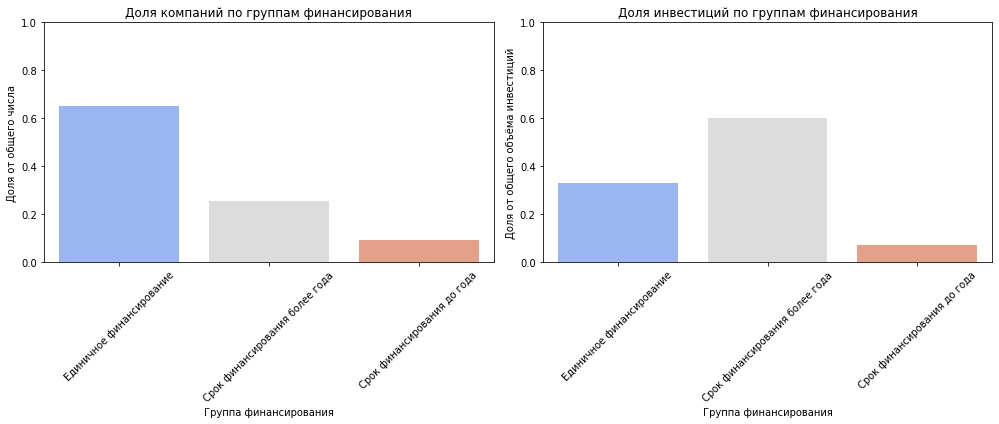

In [36]:
# Визуализация
palette = sns.color_palette('coolwarm', n_colors=3) 
categories = ['Единичное финансирование', 'Срок финансирования до года', 'Срок финансирования более года']

plt.figure(figsize=(14, 6))

# График 1: Доля по количеству компаний
plt.subplot(1, 2, 1)
sns.barplot(x=group_counts.index, y=group_counts.values, palette=palette) 
plt.title('Доля компаний по группам финансирования') 
plt.ylabel('Доля от общего числа') 
plt.xlabel('Группа финансирования') 
plt.ylim(0, 1)
plt.xticks(rotation=45)

# График 2: Доля по объёму инвестиций
plt.subplot(1, 2, 2)
sns.barplot(x=group_funding_percent.index, y=group_funding_percent.values, palette=palette) 
plt.title('Доля инвестиций по группам финансирования') 
plt.ylabel('Доля от общего объёма инвестиций') 
plt.xlabel('Группа финансирования') 
plt.ylim(0, 1)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


Сравнение долей показывает закономерность: чем больше компания финансируется, тем больший объем инвестиций имеет, но большенство стартапов не доходят до этой стадии.

**Общий вывод:**

Рынок можно назвать текучем, так как большенство компаний ограничиваются одним раундом инвестиций. Основной объем инвестиций сконцентрирован у меньшей доли комнапий, финансирование которых превышает год. Это свидетельствует о сосредоточении инвестиций и более зрелых "игроков".

### 2.2 Выделение средних и нишевых сегментов рынка

Сегмент рынка компаний указан в столбце `market`. Расчитаем, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесите к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесите к средним, а сегменты до 35 компаний отнесите к нишевым. Рассчитайте, сколько сегментов попадает в каждую из категорий.

Построем график распределения количества компаний в сегментах и отобразим на нём разделение на нишевые и средние сегменты.

In [37]:
# Проверим, сколько всего уникальных сегментов 
print("Уникальных значений market:", df_invest['market'].nunique())

Уникальных значений market: 440


In [38]:
# Рассчитайте количество компаний в каждом сегменте рынка 
market_counts = df_invest['market'].value_counts().sort_values(ascending=False)

display(market_counts)

software             5489
unknown              3961
biotechnology        3761
mobile               2725
e-commerce           2283
                     ... 
loyalty programs        1
creative                1
nutrition               1
physical security       1
shoes                   1
Name: market, Length: 440, dtype: int64

In [39]:
# Посчитаем количество компаний в каждом сегменте 
market_counts = df_invest['market'].value_counts().reset_index()
market_counts.columns = ['market', 'company_count']

# Исключим заглушку 'unknown' из анализа 
market_counts_real = market_counts[market_counts['market'] != 'unknown']

display(market_counts_real)

,market,company_count
0,software,5489
2,biotechnology,3761
3,mobile,2725
4,e-commerce,2283
5,curated web,2088
...,...,...
435,distributors,1
436,natural language processing,1
437,face recognition,1
438,visualization,1


In [40]:
# Классифицируем сегменты
def classify_segment(x):
    if x > 120:
        return 'Массовый'
    elif 35 <= x <= 120:
        return 'Средний'
    else:
        return 'Нишевый'

#  Создаем копию 
market_counts_real = market_counts_real.copy()

# Добавляем столбец с типом сегмента
market_counts_real.loc[:, 'segment_type'] = market_counts_real['company_count'].apply(classify_segment)

# Сколько сегментов в каждой категории
segment_summary = (
    market_counts_real['segment_type']
    .value_counts()
    .rename_axis('Тип сегмента')
    .reset_index(name='Количество сегментов')
)

display(segment_summary)

# Проверим первые строки
display(market_counts_real.head(10))


,Тип сегмента,Количество сегментов
0,Нишевый,334
1,Массовый,53
2,Средний,52


,market,company_count,segment_type
0,software,5489,Массовый
2,biotechnology,3761,Массовый
3,mobile,2725,Массовый
4,e-commerce,2283,Массовый
5,curated web,2088,Массовый
6,enterprise software,1557,Массовый
7,games,1374,Массовый
8,clean technology,1324,Массовый
9,health care,1294,Массовый
10,advertising,1276,Массовый


Из выборки были исключены компании, содержащие в столбце market заглушки, их количество составляет 3 961. Это необходимо, чтобы не искажать распределение по реальным сегментам

Отметим большое количество нишевых сегментов, что отражает ситуация со стартапами, работающими в узких направлениях. Хотя массовые направления встречаются реже, они концентрируют наибольшее количество компаний, а предположительно основной объем инвестиций

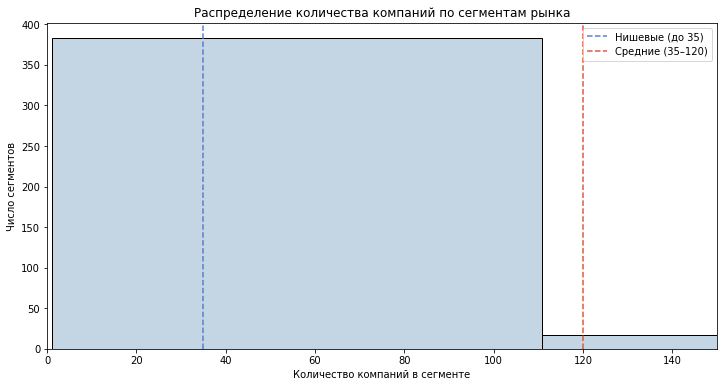

In [41]:
# График распределения компаний по сегментам

plt.figure(figsize=(12, 6))
sns.histplot(data=market_counts_real, x='company_count', bins=50, color='#b0c8db', edgecolor='black') 
plt.axvline(35, color='#5c7ece', linestyle='--', label='Нишевые (до 35)') 
plt.axvline(120, color='#de5640', linestyle='--', label='Средние (35–120)') 
plt.title('Распределение количества компаний по сегментам рынка') 
plt.xlabel('Количество компаний в сегменте') 
plt.ylabel('Число сегментов')
plt.legend()

plt.xlim(0, 150) # Ограничиваем ось х от 0 до 150

plt.show()


Большое количество сегментов рынка содержат до 35 компаний — это видно по большому столбцу слева и минимальному числу сегментов, выходящих за эту границу.
Средние сегменты встречаются реже — правее синей пунктирной и левее красной линии лишь единичные случаи.
Массовых сегментов практически нет на выбранном интервале — срез оси до 150 хорошо показывает, что абсолютное большинство остаётся в области нишевых и средних

Такое распредение может говорить о дробности структуры рынка и потенциале для развития внутри большинства ниш.


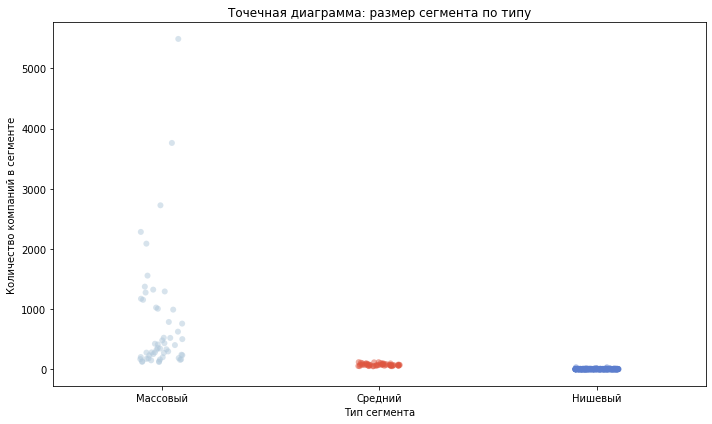

In [42]:
# Точечная диаграмма
plt.figure(figsize=(10, 6)) 
sns.stripplot(
    data=market_counts_real,
    x='segment_type',
    y='company_count',
    jitter=True,
    palette={'Массовый': '#b0c8db', 'Средний': '#de5640', 'Нишевый': '#5c7ece', 'Unknown': '#cccccc'},
    alpha=0.5,
    size=6
)
plt.title('Точечная диаграмма: размер сегмента по типу') 
plt.xlabel('Тип сегмента') 
plt.ylabel('Количество компаний в сегменте')
plt.tight_layout()
plt.show()


 - Основная масса сегментов сосредоточина в близких к нулю значениях. Это говорит о том, что в большенстве сигментов встречается редкие направления с 1-2 компаниями. 
 
- Доля массовых сегментов, с большим количеством компаний, небольшая на фоне общего распределения. Эту ситуацию можно объяснить тем, что массовые сегмены редко встречаются в стартапах, где рынок диверсифицирован по уникальным направлениям

- На графике мы видим длиннохвостое распределение, очень большое количество сегментов с маленьким размером и небольшая часть с существенным количеством компаний

Оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.



In [43]:
# Подготовим словарь классификации сегментов для подстановки

segment_map = market_counts_real.set_index('market')['segment_type'].to_dict()

# Создаём копию основного датафрейма и заменяем значения

df_invest = df_invest.copy()

def replace_market(value):
    if value not in segment_map:
        return 'unknown'  # для заглушек
    seg_type = segment_map[value]
    if seg_type == 'Массовый':
        return value  
    elif seg_type == 'Средний':
        return 'mid'
    else:
        return 'niche'

df_invest['market'] = df_invest['market'].apply(replace_market)

display(df_invest.head(10))


,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h,funding_duration_days,funding_group
0,harvard university,http://harvard.edu,|education|,education,90000000.0,operating,usa,ma,boston,cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
1,university of new brunswick,http://www.unb.ca,unknown,unknown,2000000.0,operating,unknown,unknown,unknown,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
2,dupont,http://www.dupont.com,|business services|agriculture|automotive|inve...,mid,9000000.0,operating,usa,de,"wilmington, delaware",wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
3,university of michigan,http://www.umich.edu/,|education|,education,7700000.0,operating,usa,mi,detroit,ann arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,347.0,Срок финансирования до года
4,case western reserve university,http://www.case.edu,|education|,education,540000.0,operating,usa,oh,cleveland,cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
5,xavier university,http://www.xavier.edu/,unknown,unknown,19000000.0,operating,usa,oh,cincinnati,cincinnati,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
6,tulane university,http://tulane.edu/,|education|,education,12000000.0,operating,usa,la,new orleans,new orleans,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,108.0,Срок финансирования до года
7,duke university,http://www.duke.edu,|education|,education,8700000.0,operating,usa,nc,raleigh,durham,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
8,"virginia commonwealth university, richmond",http://www.vcu.edu/,unknown,unknown,6000000.0,operating,usa,va,richmond,richmond,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
9,wegame,http://www.wegame.com,|social media|,social media,3500000.0,acquired,usa,ca,sf bay area,san francisco,...,3000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,152.0,Срок финансирования до года


In [44]:
print(df_invest['market'].value_counts().head(15))
print("\nКоличество уникальных значений после объединения:", df_invest['market'].nunique())


software               5489
mid                    3970
unknown                3961
biotechnology          3761
mobile                 2725
e-commerce             2283
curated web            2088
enterprise software    1557
games                  1374
clean technology       1324
health care            1294
advertising            1276
social media           1173
hardware + software    1155
niche                  1097
Name: market, dtype: int64

Количество уникальных значений после объединения: 56


После группировки по уникальным значениям, количество сегментов насчитывает 56. 
Отметим, что сегменты средних и нисшевых компаний укрупнены в группы, также отдельно посчитаны заглышки, чтобы не искажать результат.

Отобран топ-15 сегментов по количеству компаний. Набольшая концентрация наблюдается в сегменте програмного обеспечения - 5489. Это может говорить о низком пароге входа на рынок и стабильном интересе инвесторов. Лидирующие позиции занимают biotechnology и mobile, что отражает тренд на развитиеинноваций в области медецины и мобильных технологий. Подтверждением этого тренда являются и сегменты e-commerce и curated web, находящиеся в топе. 

Отобразим результаты на графике.

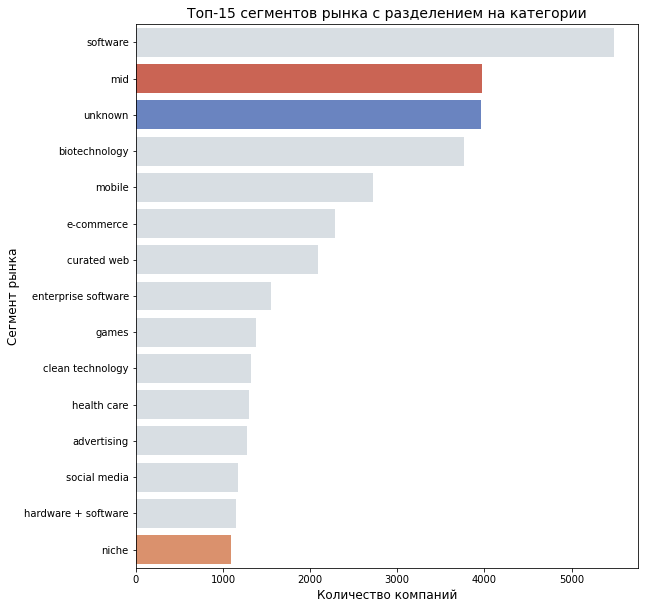

In [45]:
segment_counts = df_invest['market'].value_counts()
top_n = 15
top_segments = segment_counts.head(top_n)

# Палитра цветов
palette = {
    'mid': '#de5640',        
    'niche': '#ec8b5b',      
    'unknown': '#5c7ece',   
}

# Определим, где начинается каждая категория 
# Для этого определим позиции (индексы) сегментов, которые принадлежат к каждой группе 
massive_segments = [s for s in top_segments.index if s not in ['mid', 'niche', 'unknown']] 
mid_index = top_segments.index.get_loc('mid') if 'mid' in top_segments.index else None 
niche_index = top_segments.index.get_loc('niche') if 'niche' in top_segments.index else None

# Построение графика
plt.figure(figsize=(9, 10))
sns.barplot(
    y=top_segments.index,
    x=top_segments.values,
    palette=[palette.get(x, '#d6dee5') for x in top_segments.index]
)

plt.title(f'Топ-{top_n} сегментов рынка с разделением на категории', fontsize=14) 
plt.xlabel('Количество компаний', fontsize=12) 
plt.ylabel('Сегмент рынка', fontsize=12)

plt.show()


После объединения средних и нишевых направлений в общие группы, структура данных стала компактнее, агрегированные группы покажут обобщенные тенденции.

Соотношение типов сегментов говорит о структуре рынка: наибольшее сосредоточение компаний, вероятно и наибольший объем инвестиций находится в массовых сигментах, вроде ИТ и биотехнологий. Однако направления средних компаний тоже занимает значительну долю после укрупнения. 


**Общий вывод**

При большом числе нишевых направлений, оснавная предпренимательская активность сосредоточена в нескольких массовых сегментах. Это указывает на зрелость ИТ сегмента, биотехнологий и мобильных коммуникаций, а также интерес к данным сферам.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

По предобработанному столбцу `funding_total_usd` графическим образом оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажем интервал, в котором лежат типичные значения.

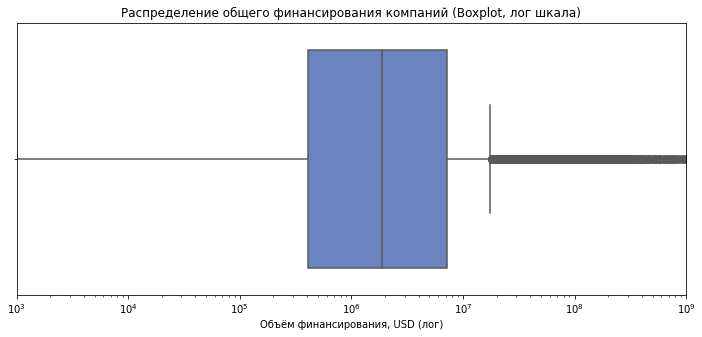

In [46]:
plt.figure(figsize=(12, 5))
sns.boxplot(x=df_invest['funding_total_usd'], color='#5c7ece')
plt.xscale('log')
plt.xlim(10**3, 10**9)  # ограничим диапазон до 1 млрд USD 
plt.title('Распределение общего финансирования компаний (Boxplot, лог шкала)') 
plt.xlabel('Объём финансирования, USD (лог)')
plt.show()



Наше распределение имеет значительную вариацию: от тысяч до миллиардов долларов, чтобы ящик с усами выглядел показательно, использована логарифмическая шкала по оси Х. 

На графике мы видим длинный правый хвост, выбросы значительно превышают медиану, это указывает, что в распределении есть отдельные компании с очень большим объемом финансироваия. Разпрос сильно увеличивается справа, что характерно для финансирования стартапов. 
Типичные значения лежат в коробке, это "норма" рынка, далее будем рассматривать именно эту часть выборки. 


**Общий вывод:**

Распределение финонсирования по компаниям сильно неравномерно, рынок характеризуется большинством компаний с небольшими суммами финансирования и меньшим количеством крупных игроков, привлекающим огромные суммы. 

Такая структура распределения типична для венчурного рынка, где финансирование концентрируется на малом числе стартапов с высоким ростом,  в то время как большая часть получет минимальные средства и ограничивается одним раундом инвестиций. 

In [47]:
# Проверим данные 
print(df_invest['market'].unique()[:10])

print(df_invest['funding_total_usd'].describe())

['education' 'unknown' 'mid' 'social media' 'hardware + software'
 'biotechnology' 'niche' 'hospitality' 'enterprise software'
 'manufacturing']
count    4.943800e+04
mean     1.365370e+07
std      1.536148e+08
min      1.000000e+00
25%      4.092990e+05
50%      1.890000e+06
75%      7.196369e+06
max      3.007950e+10
Name: funding_total_usd, dtype: float64


In [48]:
# Посмотрим типичные значения для каждого сегмента

segment_stats = df_invest.groupby('market')['funding_total_usd'].describe()
display(segment_stats)

,count,mean,std,min,25%,50%,75%,max
market,,,,,,,,
advertising,1276.0,1.194733e+07,4.063520e+07,1000.0,723937.50,3181739.0,10000000.00,1.137000e+09
analytics,760.0,1.271819e+07,5.832305e+07,10000.0,600000.00,3400000.0,9362500.00,1.201000e+09
apps,282.0,2.285473e+06,5.560694e+06,7500.0,120000.00,500000.0,1475000.00,5.000000e+07
automotive,204.0,1.943991e+07,1.170119e+08,500.0,514765.25,3135060.0,6654625.00,1.451000e+09
big data,166.0,1.005630e+07,2.615099e+07,11700.0,326250.00,2000000.0,5975000.00,2.000000e+08
biotechnology,3761.0,2.041725e+07,5.532878e+07,1000.0,1584998.00,5400000.0,20500000.00,2.400000e+09
clean technology,1324.0,3.519059e+07,9.793073e+07,3000.0,1894766.00,7500000.0,24000000.00,1.200000e+09
cloud computing,170.0,1.057605e+07,2.413516e+07,10000.0,600000.00,1860000.0,9347265.50,2.311000e+08
consulting,525.0,6.411120e+06,2.168662e+07,100.0,388349.00,1890000.0,3000000.00,3.983500e+08


In [49]:
# Функция для выявления выбросов методом IQR 
def detect_outliers_iqr(data, column):
    """Возвращает Series с True, если значение является выбросом по IQR."""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (data[column] < lower) | (data[column] > upper)

# Добавим столбец с отметкой выбросов
df_invest['outlier_IQR'] = False

for seg in df_invest['market'].unique():
    seg_mask = df_invest['market'] == seg
    df_invest.loc[seg_mask, 'outlier_IQR'] = detect_outliers_iqr(df_invest[seg_mask], 'funding_total_usd')
    
display(df_invest.head(5))

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_b,round_c,round_d,round_e,round_f,round_g,round_h,funding_duration_days,funding_group,outlier_IQR
0,harvard university,http://harvard.edu,|education|,education,90000000.0,operating,usa,ma,boston,cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,True
1,university of new brunswick,http://www.unb.ca,unknown,unknown,2000000.0,operating,unknown,unknown,unknown,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,True
2,dupont,http://www.dupont.com,|business services|agriculture|automotive|inve...,mid,9000000.0,operating,usa,de,"wilmington, delaware",wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,False
3,university of michigan,http://www.umich.edu/,|education|,education,7700000.0,operating,usa,mi,detroit,ann arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,347.0,Срок финансирования до года,True
4,case western reserve university,http://www.case.edu,|education|,education,540000.0,operating,usa,oh,cleveland,cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,False


In [50]:
# Рассчитаем долю выбросов по сегментам
outlier_share = (
    df_invest.groupby('market')['outlier_IQR']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
outlier_share.columns = ['market', 'share_outliers']

# Определим топ-10 сегментов с наибольшей долей аномального финансирования 
top_outlier_segments = outlier_share.head(10)
display(top_outlier_segments)

,market,share_outliers
0,transportation,0.189655
1,medical devices,0.180328
2,unknown,0.177228
3,hospitality,0.175299
4,fashion,0.174118
5,entertainment,0.172840
6,video,0.170940
7,medical,0.170819
8,internet,0.167785
9,travel,0.167070


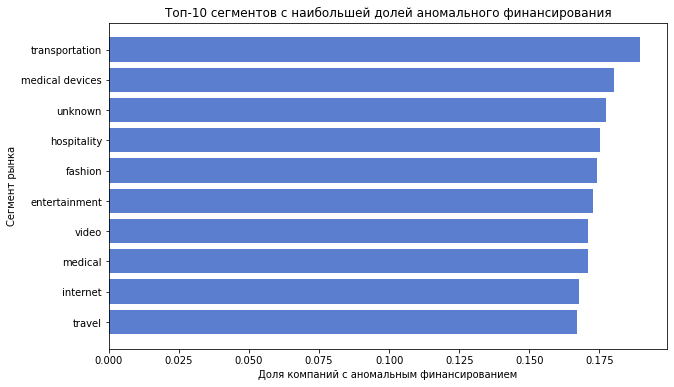

In [51]:
# Визуализируем 
plt.figure(figsize=(10,6))
plt.barh(top_outlier_segments['market'], top_outlier_segments['share_outliers'], color='#5c7ece')
plt.xlabel('Доля компаний с аномальным финансированием')
plt.ylabel('Сегмент рынка')
plt.title('Топ-10 сегментов с наибольшей долей аномального финансирования')
plt.gca().invert_yaxis()
plt.show()

Наибольшие доли аномальных компаний зафиксированы в сегметах: transportation и medical devices. Это значит, что в сегментах  относительно часто встречаются компании с финансированием, отличающимся от типичных значений. 

Высокая доля аномалий может свидетельствовать о большой неопределенности в сегментах.  Некоторые компании полуают знасчитально больше или меньше финансировнаия, чем остальные. 

В сегментах с максимальной долей аномалий инвесторы с высокой вероятностью столкнуться с вариативностью исходов: можно как заработать на сверхдоходных инвестициях, так и прогареть из-за непредскозуемости рынка. 

In [52]:
# Типичные значения 
typical_values = (
    df_invest.groupby('market')['funding_total_usd']
    .describe()[['25%', '50%', '75%']]
    .rename(columns={'50%': 'median'})
)
display(typical_values.head(10))

,25%,median,75%
market,,,
advertising,723937.50,3181739.0,10000000.0
analytics,600000.00,3400000.0,9362500.0
apps,120000.00,500000.0,1475000.0
automotive,514765.25,3135060.0,6654625.0
big data,326250.00,2000000.0,5975000.0
biotechnology,1584998.00,5400000.0,20500000.0
clean technology,1894766.00,7500000.0,24000000.0
cloud computing,600000.00,1860000.0,9347265.5
consulting,388349.00,1890000.0,3000000.0


Выводы, которые можно сделать на основании данных таблицы
- Типичные значения 
    * Большинство сегментов имеют медианные значения финансирования до 5 млн долл.
    * Самые высокие медианы наблюдаются в сегментах: clean technology (7,5 млн долл) и biotechnology (5,4 млн долл.). Эти отрасли требуют больших вложений для разработок, что отражается в больших инвестициях.
   
- Диапазон типичных значений (Q1–Q3)
    * Наибольший разброс типичных значений у clean technology и biotechnology — до десятков миллионов долларов, что говорит о высокой неоднородности компаний внутри этих сегментов
    * Более устойчивые сегменты с узким диапазоном — apps, curated web, где компании похожи по уровню привлечённых средств.

In [53]:
# Отберём 10 самых популярных сегментов
top_markets = (
    df_invest['market'].value_counts()
    .head(10)
    .index
)
# Подготовим данные 
top_data = df_invest[df_invest['market'].isin(top_markets)]

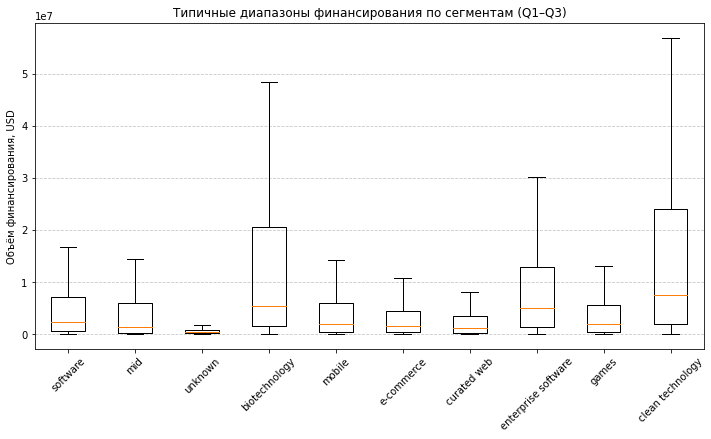

In [54]:
# Визуализация boxplot по объёму финансирования 
plt.figure(figsize=(12, 6))
plt.boxplot(
    [top_data[top_data['market'] == m]['funding_total_usd'].dropna() for m in top_markets],
    labels=top_markets,
    showfliers=False,  # без выбросов
)
plt.xticks(rotation=45)
plt.title('Типичные диапазоны финансирования по сегментам (Q1–Q3)')
plt.ylabel('Объём финансирования, USD')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Boxplot показывает значительное количество выбросов справа почти во всех сегментах — особенно у biotechnology и clean technology. Это указывает, что в этих отраслях встречаются компании, получившие исключительно крупное финансирование, сильно выделяющееся на фоне типичных значений.

Рынок стартапов очень неоднородный, цифровые компании требуют меньше ресурсов, а проекты с научной и производственной базой затрачивают гораздо больше инвестиций.

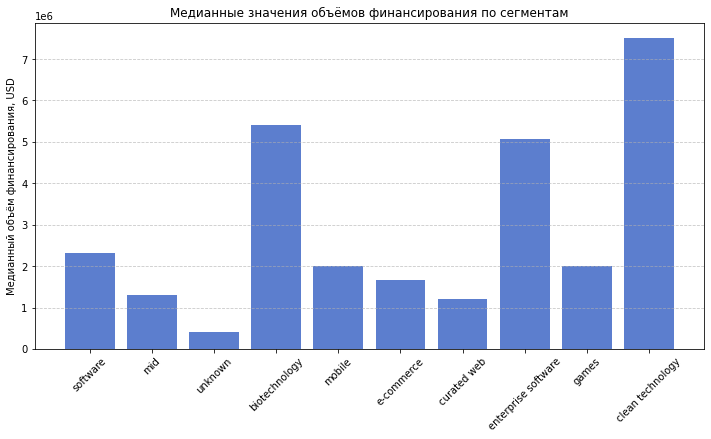

In [55]:
# Визуализация медианных значений
plt.figure(figsize=(12, 6))
plt.bar(top_markets, typical_values.loc[top_markets, 'median'], color='#5c7ece')
plt.xticks(rotation=45)
plt.title('Медианные значения объёмов финансирования по сегментам')
plt.ylabel('Медианный объём финансирования, USD')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Основные наблюдения исходя итз графика: 
•	Лидеры по медианному объёму финансирования — это сегменты clean technology и biotechnology. Для них медианные, что говорит о значительных инвестициях именно в эти отрасли.
•	Высокие медианные значения также у enterprise software и games, что показывает привлекательность этих сегментов для вложений.
•	Сегменты real, curated web характеризуются наименьшими медианами. Это свидетельствует о минимальных суммах финансирования для компаний в этих областях.

Сравнение медианных значений помогает выделить “дорогие” и “массовые” ниши рынка и использовать эту информацию для приоритезации инвестиционной стратегии.

Если цель — максимизировать капитализацию стоит обратить внимание на сегменты clean technology, biotechnology и enterprise software, где средние суммы финансирования заметно превосходят остальные отрасли. Оставшиеся сегменты могут быть более привлекательны для малых и средних сделок, либо для стратегий, ориентированных на широкий портфель.


**Общий вывод:**

Анализ аномалий позволяет расставить приоритеты, опираясь на индивидуальный риск-профиль в каждом сигменте, а сравнение медианных значений помогает выделить “дорогие” и “массовые” ниши рынка и использовать эту информацию для приоритезации инвестиционной стратегии.

Если цель — максимизировать капитализацию стоит обратить внимание на сегменты clean technology, biotechnology и enterprise software, где средние суммы финансирования заметно превосходят остальные отрасли. Оставшиеся сегменты могут быть более привлекательны для малых и средних сделок, либо для стратегий, ориентированных на широкий портфель.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим полноту данных за 2014 год. Затем исключим из датасета компании, которые ранее получили аномальное финансирование.

После исключения аномальных записей, на основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [56]:
# Проверим распределение по годам — сколько записей есть за каждый год
years = df_invest['mid_funding_at'].dt.year.value_counts().sort_index()

display(years)


1921.0        1
1960.0        3
1973.0        1
1974.0        2
1979.0        1
1982.0        3
1983.0        1
1984.0        5
1985.0        5
1986.0        4
1987.0        6
1988.0        2
1989.0        4
1990.0       12
1991.0        9
1992.0       12
1993.0       14
1994.0       12
1995.0       18
1996.0       24
1997.0       20
1998.0       45
1999.0       93
2000.0      148
2001.0       91
2002.0      111
2003.0      131
2004.0      205
2005.0      917
2006.0     1595
2007.0     2413
2008.0     2990
2009.0     3680
2010.0     4685
2011.0     5935
2012.0     7470
2013.0    10256
2014.0     8506
Name: mid_funding_at, dtype: int64

Данные позволяют оценить распределение по годам, подробнее рассмотрим 2014 г. в разрезе месяцев.

In [57]:
# Посмотрим, сколько записей за 2014 год
print(f"Количество записей за 2014 год: {years.get(2014, 0)}")

# Проверим, есть ли данные за все месяцы 2014 года
months_2014 = (
    df_invest[df_invest['mid_funding_at'].dt.year == 2014]
    ['mid_funding_at'].dt.month.value_counts().sort_index()
)
display(months_2014)

Количество записей за 2014 год: 8506


1     1013
2      750
3      829
4      818
5      774
6      932
7      874
8      774
9      699
10     651
11     362
12      30
Name: mid_funding_at, dtype: int64

Исходя из полученных данных, можно сделать вывод, что данные за 2014 г. полные, отсутствуют "пустые" месяцы.

In [58]:
# Минимальная и максимальная даты в 2014 году — чтобы окончательно убедиться, что охвачен весь год
dates_2014 = df_invest[df_invest['mid_funding_at'].dt.year == 2014]['mid_funding_at']
print(f"Минимальная дата: {dates_2014.min()}")
print(f"Максимальная дата: {dates_2014.max()}")


Минимальная дата: 2014-01-01 00:00:00
Максимальная дата: 2014-12-31 00:00:00


In [59]:
df_outliers = df_invest[df_invest['outlier_IQR'] == True]

# Исключаем аномальные компании
df_clean = df_invest[~df_invest['name'].isin(df_outliers['name'])]
print(f"Размер исходного датасета: {df_invest.shape[0]}")
print(f"Размер после удаления аномалий: {df_clean.shape[0]}")



Размер исходного датасета: 49438
Размер после удаления аномалий: 42496


После очистки выбросов, размер данных составляет - 42 496 строк.

In [60]:
# Группируем по годам и считаем количество раундов
rounds_by_year = df_clean.groupby(df_clean['mid_funding_at'].dt.year)['funding_rounds'].count()

# Выбираем только годы, где было 50 и более раундов
active_years = rounds_by_year[rounds_by_year >= 50].index
print("Годы, в которых ≥50 раундов финансирования:", list(active_years))

# Оставляем только компании, получавшие финансирование в эти годы
df_final = df_clean[df_clean['mid_funding_at'].dt.year.isin(active_years)]
print(f"Размер датасета после фильтрации по активным годам: {df_final.shape[0]}")

display(df_final.head(10))

Годы, в которых ≥50 раундов финансирования: [1999.0, 2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]
Размер датасета после фильтрации по активным годам: 42299


,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_b,round_c,round_d,round_e,round_f,round_g,round_h,funding_duration_days,funding_group,outlier_IQR
2,dupont,http://www.dupont.com,|business services|agriculture|automotive|inve...,mid,9000000.0,operating,usa,de,"wilmington, delaware",wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,False
4,case western reserve university,http://www.case.edu,|education|,education,540000.0,operating,usa,oh,cleveland,cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,False
9,wegame,http://www.wegame.com,|social media|,social media,3500000.0,acquired,usa,ca,sf bay area,san francisco,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,152.0,Срок финансирования до года,False
11,mayne pharma,http://www.maynepharma.com,|biotechnology|,biotechnology,2705000.0,operating,unknown,unknown,unknown,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,False
12,siemens,http://www.siemens.com,|clean energy|automotive|hardware + software|,hardware + software,8900000.0,operating,deu,unknown,munich,munich,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,False
13,university of rochester,http://www.rochester.edu,unknown,unknown,409299.0,operating,usa,ny,"rochester, new york",rochester,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,False
16,michigan state university,http://msu.edu,|education|universities|,education,3900000.0,operating,usa,mi,lansing,east lansing,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,False
19,laclede group,http://www.thelacledegroup.com,|utilities|,niche,3800000.0,operating,usa,mo,st. louis,st louis,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,False
21,"lsu, baton rouge",http://lsu.edu,|education|,education,2000000.0,operating,usa,la,baton rouge,baton rouge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,False
22,watkins hire,http://watkinshire.co.uk,|enterprise software|,enterprise software,15304039.0,operating,unknown,unknown,unknown,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,False


Результат после выполнения всех шагов:
1.	Проверено, что данные за 2014 год полные, информация присутсвует по каждому месяцу
2.	Аномальные компании исключены.
3.	Оставлены только годы с достаточным числом наблюдений, а именно более 50 раундов. Получившийся диапозон дат: 1999-2014 гг.
4.	Получен финальный очищенный датасет df_final, пригодный для дальнейшего анализа структуры и динамики инвестиций.


### 3.3. Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Будем ориентироваться на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также построим график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравним графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

In [61]:
# Список столбцов с типами финансирования 
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

# Суммарный объём инвестиций по каждому типу 
funding_sums = df_final[funding_types].sum().sort_values(ascending=False)

# Популярность (сколько компаний имело ненулевое значение) 
funding_counts = (df_final[funding_types] > 0).sum().sort_values(ascending=False)

# Объединим в один DataFrame
funding_summary = pd.DataFrame({
    'total_usd': funding_sums,
    'company_count': funding_counts
}).sort_values('total_usd', ascending=False)

# Добавим подписи с типами финансирования
funding_summary.reset_index(inplace=True)
funding_summary.rename(columns={'index': 'funding_type'}, inplace=True)

display(funding_summary)

,funding_type,total_usd,company_count
0,venture,1.086809e+11,17514
1,seed,8.976399e+09,13152
2,debt_financing,7.262982e+09,3094
3,private_equity,3.818493e+09,565
4,angel,2.278402e+09,2873
5,grant,1.670441e+09,967
6,undisclosed,1.653620e+09,765
7,post_ipo_equity,1.495505e+09,144
8,convertible_note,5.040403e+08,505
9,post_ipo_debt,2.267183e+08,25


Основываясь на данных таблицы отметим, что самый популярный по сумме и числу компаний тип финансирования - венчурное. Этот тип абсолютно доминирует по обоим показателям. 

Второе и третье места занимают посевое (seed) и заемное (debt_financing	) финансирование. 

Среди "второстепенных" форматов  встречаются private_equity, angel и grant, последующие типы заниают значительно меньшие доли по объемам финансировнаия и числу компаний.

Визуалтизируем отдельно типы финансирования по объемам инвестиций и количеству компаний.

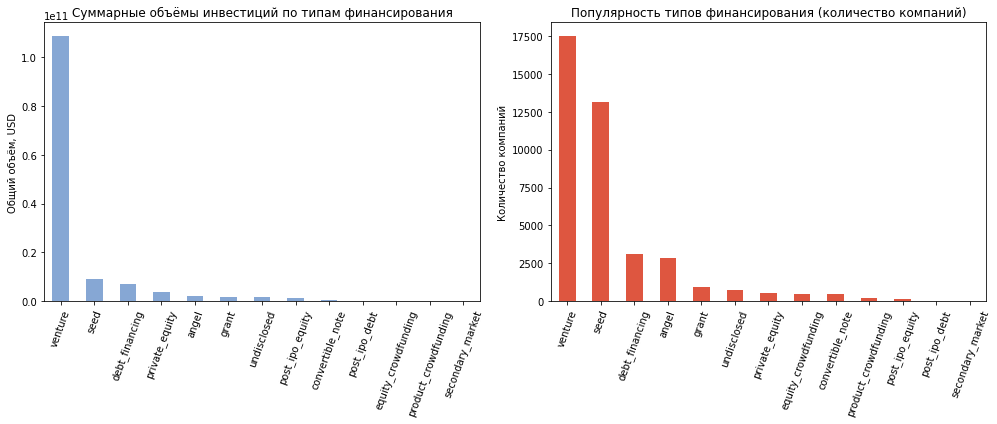

In [62]:
plt.figure(figsize=(14,6))

# График 1 — общий объём инвестиций
plt.subplot(1,2,1)
funding_sums.plot(kind='bar', color='#86a7d4') 
plt.title('Суммарные объёмы инвестиций по типам финансирования') 
plt.ylabel('Общий объём, USD')
plt.xticks(rotation=70)

# График 2 — популярность типов финансирования
plt.subplot(1,2,2)
funding_counts.plot(kind='bar', color='#de5640') 
plt.title('Популярность типов финансирования (количество компаний)')
plt.ylabel('Количество компаний')
plt.xticks(rotation=70)

plt.tight_layout()
plt.show()


Венчурное и посевное финансирование - базовые пути привлесчения средств для стартапов и молодых компаний, здесь основной поток проектов и средств.

Долговое финансированиеи безнес-ангелы также играют значительную роль, хоть и более нишевую. 

Прочие инструменты используются либо отдельными компаниями, либо специализируются на редких сценариях (выкупы, гранты, секьюритизация)

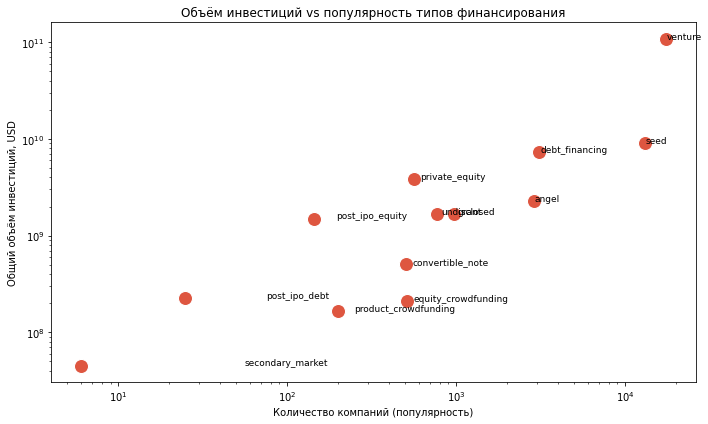

In [63]:
# Построим график
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=funding_summary,
    x='company_count', y='total_usd',
    s=200, color='#de5640'
)

# Подписи к точкам
for i in range(len(funding_summary)):
    plt.text(
        funding_summary['company_count'][i] + 50,
        funding_summary['total_usd'][i],
        funding_summary['funding_type'][i],
        fontsize=9
    )

plt.title('Объём инвестиций vs популярность типов финансирования') 
plt.xlabel('Количество компаний (популярность)') 
plt.ylabel('Общий объём инвестиций, USD')
plt.xscale('log')
plt.yscale('log')

plt.tight_layout()
plt.show()


Визуализация, совмещающая объем инвестиций и число компаний позволяет сделать дополнительные выводы о структуре рынкафинансирования.

Если разделить типы финансирования на категории, получем следующую градацию: 
- venture. Этот тип финансирования доминирует в разных направлениях, это подтверждает лидерство венчурного капитала как главной точки притяжения средств и стартапов в рынке 
- seed и debt_financing. Вторая категория с большим числом компаний, однако по суммарному объему они уступают. Это свидетельствует тому, что посевное и долговое финансирование часто привлекается малыми суммами или короткими раундами.
- private_equity и angel. Следующая категория имеет довольно умеренные объемыинвестиций, но встречается у большего количества компаний, чем сугубо нишевые инструменты
- Прочие типы (crowdfunding, secondary_market и др ). Прочие типы располагаются в левом нижнем углу: и число компаний и общиеобъемы средств здесь минимальны. Данные типы остаются оченьредкими по сравнению с массовыми подходами

**Общий вывод:**

Таким образом, можно сделать вывод, что структуру рынка определяют несколько классических типов финансирования. Это ценно при принятии решений о запуске нового стартапа или выборе инвестиционной стратегии.

Построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

In [64]:
# Суммарные объёмы возвратов за весь период 
returns_sum = df_returns[funding_types].sum().sort_values(ascending=False)

# Для таблицы с данными
returns_sum_df = returns_sum.reset_index() 
returns_sum_df.columns = ['Тип финансирования', 'Суммарный объём возвратов (USD)']
display(returns_sum_df)

,Тип финансирования,Суммарный объём возвратов (USD)
0,venture,40578.62
1,debt_financing,4734.85
2,private_equity,3587.33
3,seed,2382.24
4,angel,1509.23
5,post_ipo_equity,1104.96
6,undisclosed,730.88
7,post_ipo_debt,91.03
8,convertible_note,34.79
9,secondary_market,5.20


Как и с объемами инвестиций, венчурное финансирование занимает лидирующую позиция по возвратам - 40 578 дол. Это в разы  больше, чем у других типов, что оправдано его главенствующей позиции по количеству компаний и объемам финансирования. 

Заемное финансирование и частный капитал на втором и третьем месте. Их ссумарная доля значительно меньше возвратов по венчурному финансированию, однако также отражает их значимость для возврата инвестиций.

Посевное финансирование и бизнес-ангелы также дают значительные возвраты, но масштаб их значительно меньше.

Отсальные типы показывают почти нулевые возвраты по сравнению с лидерами.

Форматы с самыми большими возвратами полностью совпадают с лидерами по объемам финансирования и количеству компаний, получается возвратная активность идет вслед за массовыми инвестициями.

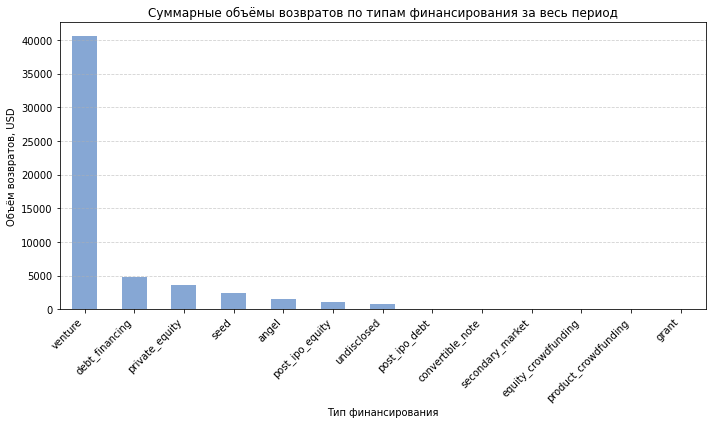

In [65]:
# Построим график
plt.figure(figsize=(10,6))
returns_sum.plot(kind='bar', color='#86a7d4')

plt.title('Суммарные объёмы возвратов по типам финансирования за весь период') 
plt.ylabel('Объём возвратов, USD') 
plt.xlabel('Тип финансирования') 
plt.xticks(rotation=45, ha='right') 
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Диаграмма наглядно показывает, что рынок возвратов практически полностью формируется за счет венчурного, долгового и частично акционерного финансирования, альтернативные же формы пока не обеспечивают ощутимой доли возвратов.


**Общий вывод:**

Максимальная эффективность наблюдается там же, где сосредоточено основное движение средств, а именно в венчурном и договом финансировании.

Остальные источники либо несут более высокий риск невозврата, либо имеют изначально невозвратную модель.

При планировании инвестиционной стратегии, стоит обратить внимание на массовые и институциональные формы финансирования, так как там максимальны и сами инвестиции и возвраты.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, расчитаем для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы построим графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).


In [66]:
# Сделаем копию df_final
df_final=df_final.copy()

# Создаем столбец с средним финансированием за раунд 
df_final.loc[:,'avg_funding_per_round'] = df_final.apply(
    lambda row: row['funding_total_usd'] / row['funding_rounds']
    if row['funding_rounds'] and row['funding_rounds'] > 0 else None,
    axis=1)


In [67]:
# Берём год из столбца mid_funding_at для группировки 
df_final['year'] = df_final['mid_funding_at'].dt.year

# Средний размер раунда по годам (медиана) 
median_funding = df_final.groupby('year')['avg_funding_per_round'].median()

# Общее количество раундов за год
total_rounds = df_final.groupby('year')['funding_rounds'].sum()

df_table = pd.DataFrame ({ 'Средний размер раунда': median_funding,
                          'Общее количество раундов':total_rounds
    
})


display(df_table)

,Средний размер раунда,Общее количество раундов
year,,
1999,1.054755e+06,88.0
2000,1.653598e+06,144.0
2001,1.000000e+06,85.0
2002,1.500000e+06,148.0
2003,1.160058e+06,159.0
2004,2.000000e+06,207.0
2005,3.750000e+06,975.0
2006,3.000000e+06,1804.0
2007,2.125000e+06,2851.0


По данным таблицы можно заметить, что до 2005 г. количество раундов было сравнительно небольшим, затем начинается стремительный рост. Пик количества раундов зафиксирован в 2013 г. в 2014г. наблюдается спад, но показатель все равно намного выше начала периода.

К 2014 году типичные суммы финансирования за раунд существенно уменьшаются, в 2013 зафиксировано падение до исторического минимума за пирод наблюдения. 

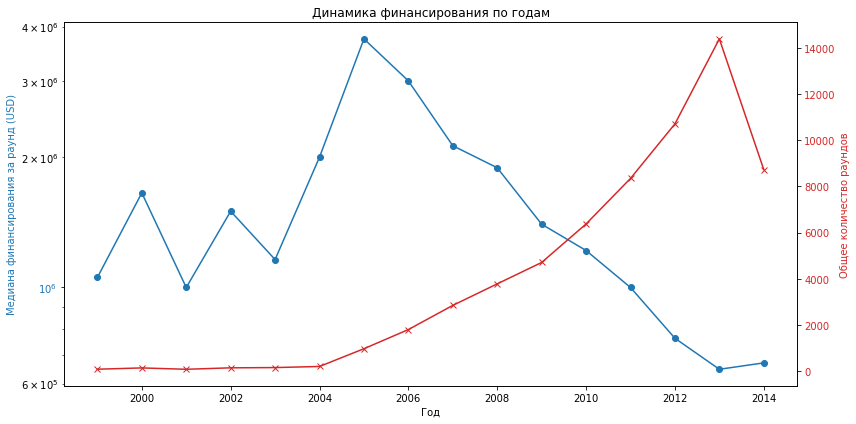

In [68]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Год')
ax1.set_ylabel('Медиана финансирования за раунд (USD)', color=color1) 
ax1.plot(median_funding.index, median_funding.values, color=color1, marker='o', label='Средний размер раунда') 
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_yscale('log')

ax2 = ax1.twinx()  # второй график поверх первого
color2 = 'tab:red'
ax2.set_ylabel('Общее количество раундов', color=color2) 
ax2.plot(total_rounds.index, total_rounds.values, color=color2, marker='x', label='Количество раундов') 
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Динамика финансирования по годам')
fig.tight_layout()
plt.show()


В период с 2005 г. по 2014 г. рынок прошел фазу роста раундов и падение среднего размера финансирования, отражая эволюцию от концентрации капиталов к массовому финансированию многих компаний небольшими чеками. Это может свидетельствовать о росте конкуренции и приоритете на раннее финансирование большего числа проектов.

Средний размер финансирования за раунд:
- Вначале 2000-х годов наблюдается рост среднего размера финансирования
- Пик среднего размера финансирования в рамках одного раунда пришелся на 2005 г. 
- После 2005 г. наблюдается спад с минимальным значением в 2013 г. 

Общее количество раундов.
- До 2005 года количество раундов "стелится" по оси Х и не привышает 250. Далее заметен быстрый но плавный рост с пиком количества в 2013 г.
- В 2014 г. можем заметить резкий спад, но количество не достигает показателей начала отчетного периода. 


**Общий вывд:** 

Рынок пережил смещение фокуса: от крупных инвестиционных раундов к большому числу небольших сделок.

Такая динамика характерна для зрелых рынков: после этапа массовых крупных вложений появляется большой поток малых инновационных проектов, что повышает общее количество раундов, но снижает их средний размер.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберите из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразим, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Для рассмотрения возьмем только массовые сегменты, а средние и нишевые исключим.



In [69]:
# mass_segments — список массовых сегментов, уже известный из вашего этапа сегментации 
mass_segments = [m for m in df_invest['market'].unique() if m not in ['mid', 'niche', 'unknown']]

print(mass_segments)

# Группируем по году и сегменту
df_final['funding_year'] = df_final['mid_funding_at'].dt.year

pivot = (
    df_final[df_final['market'].isin(mass_segments)]
    .groupby(['funding_year', 'market'])['funding_total_usd']
    .sum()
    .unstack('market')
)
display(pivot)


['education', 'social media', 'hardware + software', 'biotechnology', 'hospitality', 'enterprise software', 'manufacturing', 'finance', 'design', 'nonprofits', 'software', 'curated web', 'health care', 'health and wellness', 'media', 'clean technology', 'financial services', 'web hosting', 'e-commerce', 'automotive', 'medical', 'fashion', 'security', 'networking', 'analytics', 'semiconductors', 'public relations', 'travel', 'consulting', 'real estate', 'technology', 'music', 'advertising', 'games', 'mobile', 'sports', 'medical devices', 'internet', 'photography', 'news', 'messaging', 'search', 'video', 'transportation', 'marketplaces', 'entertainment', 'saas', 'cloud computing', 'big data', 'sales and marketing', 'apps', 'social network media', 'startups']


market,advertising,analytics,apps,automotive,big data,biotechnology,clean technology,cloud computing,consulting,curated web,...,social media,social network media,software,sports,startups,technology,transportation,travel,video,web hosting
funding_year,,,,,,,,,,,,,,,,,,,,,
1999,3531739.0,10774916.0,NaN,NaN,NaN,NaN,NaN,NaN,2005200.0,2685000.0,...,984509.5,NaN,3.134759e+07,NaN,NaN,6000000.0,NaN,1600000.0,NaN,12385764.0
2000,17651739.0,14822803.0,NaN,NaN,NaN,NaN,NaN,11500000.0,4500000.0,2217500.0,...,NaN,NaN,3.635853e+07,NaN,NaN,NaN,NaN,1650230.0,NaN,104128854.0
2001,8778321.0,3400000.0,NaN,NaN,NaN,NaN,NaN,NaN,1890000.0,2740000.0,...,650000.0,NaN,1.425018e+07,NaN,NaN,22160000.0,NaN,NaN,NaN,15000000.0
2002,24500000.0,7500000.0,NaN,NaN,NaN,NaN,3.439044e+07,NaN,NaN,5867500.0,...,NaN,NaN,1.082152e+08,200000.0,NaN,11000000.0,NaN,NaN,NaN,8785764.0
2003,17500000.0,7240000.0,NaN,4530000.0,NaN,8.553118e+07,9.114794e+07,NaN,NaN,4985000.0,...,5000.0,NaN,5.209954e+07,NaN,NaN,NaN,NaN,NaN,5000000.0,NaN
2004,20592159.0,3000000.0,NaN,NaN,NaN,5.051964e+07,5.042795e+07,NaN,NaN,38102500.0,...,NaN,NaN,1.287626e+08,NaN,NaN,1750000.0,2000000.0,10230000.0,14704000.0,35785764.0
2005,134522978.0,85814044.0,NaN,6270120.0,NaN,4.908636e+08,2.692000e+07,1860000.0,32062000.0,38935000.0,...,10427009.5,5200000.0,9.603154e+08,1882200.0,NaN,50728425.0,NaN,16100000.0,8190682.5,429332632.0
2006,208272991.0,139701311.0,1310600.0,12660000.0,NaN,9.143005e+08,7.327389e+07,9951809.0,25855548.0,126324509.0,...,46773408.5,6914383.0,1.480712e+09,900000.0,NaN,22791000.0,NaN,11700000.0,35171772.0,675154983.0
2007,560609648.0,52229000.0,NaN,21500000.0,7780000.0,1.718242e+09,6.472112e+08,23354343.0,50796345.0,251788075.0,...,75785554.0,16012483.0,1.357906e+09,10301580.0,NaN,180190209.0,5416006.5,34450000.0,42738353.0,329478741.0


In [70]:
# Защита от пропусков: сравниваем только там, где есть оба года 
growing_segments = [
    seg for seg in pivot.columns
    if ((2013 in pivot.index) and (2014 in pivot.index) and (pivot.loc[2014, seg] > pivot.loc[2013, seg])) ] 
pivot_grow = pivot[growing_segments]


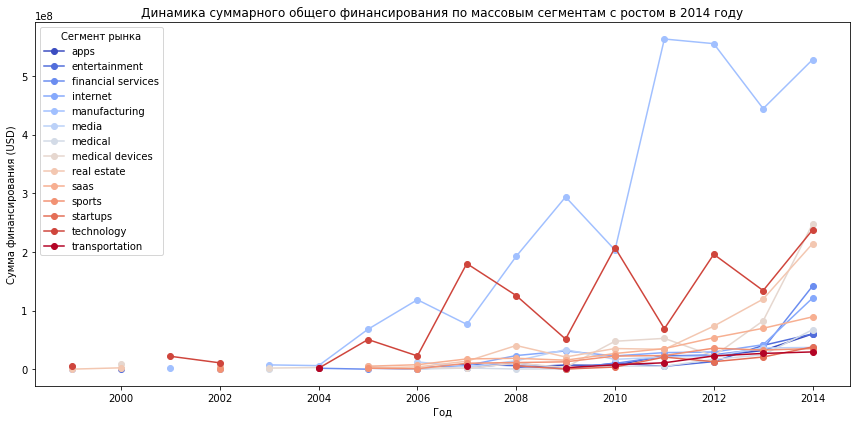

In [71]:
# Получаем список цветов из палитры coolwarm для нужного количества линий
cmap = plt.get_cmap('coolwarm')
n_lines = len(pivot_grow.columns)
colors = [cmap(i / (n_lines - 1)) for i in range(n_lines)]

# Строим каждую линию с индивидуальным цветом из палитры
ax = pivot_grow.plot(figsize=(12, 6), marker='o', color=colors)

plt.title('Динамика суммарного общего финансирования по массовым сегментам с ростом в 2014 году')
plt.xlabel('Год')
plt.ylabel('Сумма финансирования (USD)') 
plt.legend(title='Сегмент рынка')
plt.tight_layout()
plt.show()


На графике показана динамика суммарного объёма финансирования по массовым сегментам рынка, которые показали рост именно в 2014 году.

Максимальный и самый устойчивый рост с 2010-х годов демонстрируют такие сегменты, как apps, medical devices, technology и transportation. Эти сегменты показывают самые высокие значения к 2014 году, их траектории резко идут вверх относительно других.

Для некоторых сегментов (например, media, manufacturing) траектория характеризуется чередованием подъёмов и спадов. Это может быть результатом того, что крупные суммы периодически сконцентрированы в отдельных компаниях/сделках.


### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Выясним какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Для каждого года и каждого вида финансирования рассчитаем нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, заменим на пропуски.


In [72]:
# Ваши типы финансирования
types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
    'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
    'post_ipo_debt', 'secondary_market', 'product_crowdfunding'
]

# Создаём DataFrame для результирующих долей 
return_shares = pd.DataFrame()

for t in types:
    # Проверим, есть ли оба столбца (привлечённые и возвращённые средства)
    returned_col = f'{t}_return' if f'{t}_return' in df_returns.columns else t
    funded_col = f'{t}_in' if f'{t}_in' in df_final.columns else t
    if (returned_col in df_returns.columns) and (funded_col in df_final.columns):
        year = df_final['year'] if 'year' in df_final.columns else df_returns['year']
        # Группируем по году (sum на всякий случай, если не агрегированы)
        funded_sums = df_final.groupby('year')[funded_col].sum()
        returned_sums = df_returns.groupby('year')[returned_col].sum()
        # Совмещаем годы (на всякий случай)
        aligned = pd.DataFrame({'funded': funded_sums, 'returned': returned_sums})
        share = aligned['returned'] / (aligned['funded'] + 1e-60)
        # Отбрасываем неадекватные выбросы (>2)
        share[share > 2] = np.nan
        return_shares[t] = share    
return_shares.index.name = 'year'

display(return_shares)

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
1999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000,9.964712e-07,2.417205e-07,0.000000e+00,1.440261e-06,0.000000e+00,8.660000e-07,2.669564e-07,0.0,0.000000e+00,2.710694e-07,0.000000e+00,2.591054e-08,0.000000e+00
2001,1.079592e-06,2.146251e-07,0.000000e+00,5.874833e-07,NaN,4.490000e-06,1.180000e-06,0.0,0.000000e+00,NaN,0.000000e+00,NaN,0.000000e+00
2002,6.297066e-07,6.822818e-07,0.000000e+00,1.099500e-06,NaN,2.233882e-07,1.136667e-06,0.0,2.013333e-07,1.133333e-06,0.000000e+00,NaN,0.000000e+00
2003,5.052762e-07,8.087120e-07,0.000000e+00,9.143969e-07,NaN,1.038095e-06,6.057203e-07,0.0,NaN,NaN,0.000000e+00,NaN,0.000000e+00
2004,5.874096e-07,1.135038e-06,0.000000e+00,4.276793e-06,NaN,6.478101e-07,9.963380e-07,0.0,NaN,NaN,0.000000e+00,NaN,0.000000e+00
2005,7.671189e-07,6.170206e-07,0.000000e+00,1.529281e-06,NaN,3.867917e-07,7.369398e-07,0.0,4.800000e-07,7.318565e-07,0.000000e+00,NaN,0.000000e+00
2006,9.673958e-07,4.094705e-07,NaN,8.034343e-07,1.663181e-07,1.133213e-06,7.163630e-07,0.0,1.053720e-06,NaN,0.000000e+00,NaN,0.000000e+00
2007,3.938426e-07,3.668525e-07,NaN,7.048514e-07,3.462445e-07,6.920703e-07,8.650830e-07,0.0,2.054989e-06,2.030000e-06,0.000000e+00,NaN,0.000000e+00


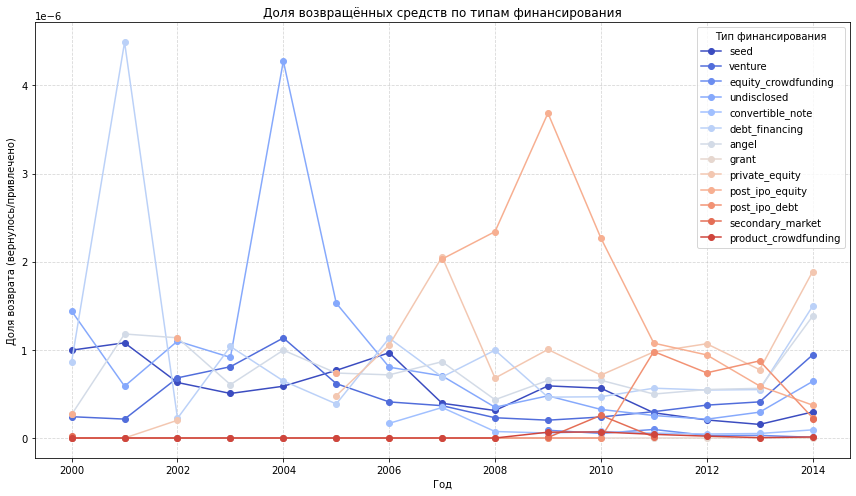

In [73]:
# Визуализация

plt.figure(figsize=(12, 7))
for i, t in enumerate(return_shares.columns):
    plt.plot(return_shares.index, return_shares[t], marker='o', label=t, color=colors[i])
plt.title('Доля возвращённых средств по типам финансирования')
plt.xlabel('Год')
plt.ylabel('Доля возврата (вернулось/привлечено)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Тип финансирования')
plt.tight_layout()
plt.show()


На графике показана динамика суммарного объёма финансирования по массовым сегментам рынка, которые показали рост именно в 2014 году.

Максимальный и самый устойчивый рост с 2010-х годов демонстрируют такие сегменты, как apps, medical devices, technology и transportation. Эти сегменты показывают самые высокие значения к 2014 году, их траектории резко идут вверх относительно других.

В некоторых сегментах наблюдаются заметные скачки — например, apps в 2012 и 2013 годах. Это может свидетельствовать о крупных сделках или появлении новых кластеров компаний.


**Общий вывод:**

К 2014 году наиболее быстрый и устойчивый рост наблюдается в сегментах apps, medical devices, technology, transportation и частично internet. Именно в этих секторах массовый рынок концентрирует основную часть дополнительных вложений, что указывает на стратегические тренды отрасли и высокую динамику развития данных рынков. Стабильные, но менее резкие темпы роста в остальных сегментах подтверждают диверсификацию инвестиций, но также свидетельствуют, что основные инвестиционные возможности и прорывы сосредоточены в технологических и digital-направлениях.

Построим график, на котором отобразите нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.


In [74]:
# Типы финансирования, которые анализируем 
selected_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

return_share = pd.DataFrame()

for t in selected_types:
    # funds — привлечённые за год, returns — возвращённые за год
    funds = df_final.groupby('year')[t].sum()
    returns = df_returns.groupby('year')[t].sum()
    share = returns / (funds + 1e-60)
    share[share > 2] = np.nan
    return_share[t] = share

returns_share_df = pd.DataFrame(return_share)

display(returns_share_df)

,venture,debt_financing,private_equity,seed,angel
year,,,,,
1999,NaN,NaN,NaN,NaN,NaN
2000,2.417205e-07,8.660000e-07,0.000000e+00,9.964712e-07,2.669564e-07
2001,2.146251e-07,4.490000e-06,0.000000e+00,1.079592e-06,1.180000e-06
2002,6.822818e-07,2.233882e-07,2.013333e-07,6.297066e-07,1.136667e-06
2003,8.087120e-07,1.038095e-06,NaN,5.052762e-07,6.057203e-07
2004,1.135038e-06,6.478101e-07,NaN,5.874096e-07,9.963380e-07
2005,6.170206e-07,3.867917e-07,4.800000e-07,7.671189e-07,7.369398e-07
2006,4.094705e-07,1.133213e-06,1.053720e-06,9.673958e-07,7.163630e-07
2007,3.668525e-07,6.920703e-07,2.054989e-06,3.938426e-07,8.650830e-07


Венчурное финансирование (venture) демонстрирует относительно стабильную, пусть и низкую, долю возвратов с редкими всплесками в отдельные годы (например, небольшой подъем в 2008–2010 и рост к 2014 году).

Абсолютные значения доли возвратов для всех типов крайне малы, что говорит о том, что возвращается только небольшая часть от объёма вложенных средств. Это типично для венчурного и посевного финансирования, где высокий риск и доля неудачных инвестиций заложены в саму модель рынка.

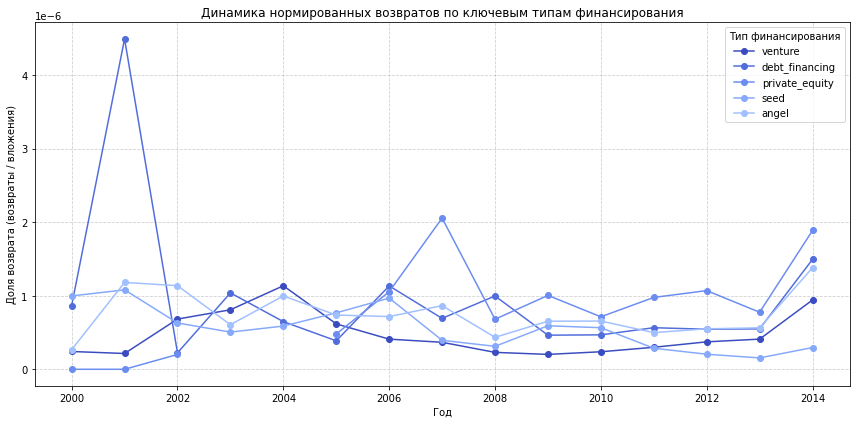

In [75]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(selected_types):
    plt.plot(returns_share_df.index, returns_share_df[col], marker='o', label=col, color=colors[i])
plt.title('Динамика нормированных возвратов по ключевым типам финансирования')
plt.xlabel('Год')
plt.ylabel('Доля возврата (возвраты / вложения)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Тип финансирования')
plt.tight_layout()
plt.show()


С 2010-х годов все типы демонстрируют большую равномерность (меньше разовых сильных колебаний), что говорит о «зрелости» рынка начальных инвестиций и большем контроле над инвестиционными потоками.

В 2014 году почти все типы показывают небольшой рост нормированных возвратов — это может быть связано с качественным улучшением отбора проектов или удачным стечением экономических факторов для экзитов.

Тем не менее, разница между типами финансирования по возвратам незначительна, все кривые располагаются очень близко друг к другу.

**Общий вывод:**

Для всех видов финансирования наблюдается стабильно низкая доля возвратов вложенных средств. Отдельные пики в динамике связаны скорее со случайными разовыми событиями, а не с устойчевой тенденцией повышения возвратов. Для инвесторов долгосрочная доходность будет определятся способностью находить редкие проекты, кооторые выстрелят, так как ориентироваться на структурный рост возвратов по рынку 


## Шаг 5. Итоговый вывод и рекомендации

Представьте, что на календаре 2015 год. Опираясь на результаты анализа, дайте рекомендацию заказчику:

* в какую отрасль стоит инвестировать;
* какой тип финансирования при этом будет наиболее уместным.

Подведите итоги проекта:
* опишите, какие шаги были выполнены;
* какие выводы удалось сделать;
* насколько выводы согласуются между собой или, наоборот, вызывают сомнения.



**В ходе исследования были выполнены следующие шаги:**

- Сбор и подготовка данных: проведена очистка, стандартизация, удаление выбросов и аномалий в инвестиционном датасете (funding_total_usd, funding_rounds, даты, сегменты рынка).
- Классификация сегментов: построено разбиение рынка на массовые, средние и нишевые сегменты по числу игроков; остальные сегменты отнесены к “niche” или “mid”.
- Анализ распределения: визуализировано распределение объемов финансирования, найдены типичные и экстремальные значения, рассчитана медиана/характерные интервалы по сегментам и в целом.
- Динамика по годам: рассчитаны и визуализированы динамика среднего объема раунда, общего числа раундов по годам, а также объема финансирования по отраслям.
- Исследование отраслей-лидеров: идентифицированы сегменты с наибольшим и самым устойчивым ростом по объёму финансирования — apps, technology, medical devices, transportation и др.
- Сравнение типов финансирования: выполнена агрегация долей возвратов, выявлены наиболее успешные форматы (venture и debt financing) как по объему, так и по числу сделок.
- Оценка возвратов: рассчитаны нормированные значения долей возвратов по каждому типу, отмечена их низкая, но стабильная величина во всем венчурном рынке.
- Сформулированы основные выводы

**Выводы по исследованию:**

- Выявлено явное лидерство технологических, digital и медицинских секторов по скорости и объёму роста подтверждается по разным метрикам и годам.
- Венчурное финансирование наиболее массовое, устойчивое и возвратное в ключевых сегментах, незаменимо для экспансии в быстрорастущие рынки.
- Большинство альтернативных инструментов и нишевых рынков остаются малозначимы на фоне общего потока, хотя могут быть полезны в отдельных уникальных стратегиях.
- Ожидания по возвратам для индустрии в целом остаются традиционно низкими, сильный эффект производят единичные крупные успешные сделки — это типичная венчурная математика.

**Согласованность выводов между собой:**

- Ключевые тренды прослеживаются и по динамике общего финансирования, и по числу компаний, и по возвратам капитала, что подтверждает надежность анализа. 
- Доля возвратов остаётся очень низкой у всех типов финансирования — это формально согласуется с логикой высокорискованных рынков, но требует внимательности в формировании портфеля. Краткие всплески в отдельных сегментах (angel, grant и др.) связаны скорее с разовыми случаями, чем с устойчивыми возможностями.
- Фокус смещается к инновациям, цифровизации, медицине и сложному транспорту. Именно здесь можно ожидать максимального роста и потенциального выхода на лидирующие мультипликаторы.


**Рекомендации заказчику:**

Топ-отрасли для инвестирования:

- Технологии (technology, apps, internet)
- Медицинские технологии и биотех (medical devices, medical)
- Транспорт и логистика (transportation)

Эти сегменты в 2013–2014 годах показали наибольший и самый устойчивый рост по суммарному объёму финансирования, демонстрировали лидерство по массе привлекаемых инвестиций и привлекают внимание как венчурных, так и институциональных инвесторов.

Наиболее уместный тип финансирования:

- Венчурное финансирование (venture). Этот формат традиционно лидирует как по совокупному объёму, так и по числу компаний, остаётся главным драйвером развития массовых инновационных отраслей и связан с крупнейшими объёмами возвратов средств.
- Для ранней стадии инноваций также целесообразно seed-инвестирование и (в меньшей степени) debt financing, если нужно минимизировать риски.


**Резюме:**

В 2015 году инвестору рационально направить средства в технологии и медицину с упором на венчурное и раннее финансирование. Исследование показало, что именно эти сегменты выдают наивысший темп и концентрацию капиталов, а структура рынка полностью соответствует тенденциям чем выше риск, тем выше доходность. Выбор венчурных инструментов на данных рынках — наиболее сбалансированная стратегия для извлечения выгоды из текущего инвестиционного цикла.